# FinAgent — System Reference

A **guided tour** of the FinAgent financial-research agent: what each part does,
how data flows through it, and how performance changes over time. Every code cell
here *imports from the backend and calls it* — no logic is defined in the
notebook. Read top to bottom to understand the system; run top to bottom to see
it work on real inputs.

> 💡 This is a reference document, not a scratch pad. If you want to change
> behaviour, edit the `finagent/` package and re-run the relevant cell.

## Section 0 — Configuration

All paths, collection names, and keys live here and nowhere else. The second cell
runs a health check so you know the environment is ready before running anything.

In [13]:
# Hot-reload edited finagent modules so notebook cells pick up code changes
# without a kernel restart (handy while implementing phases iteratively).
%load_ext autoreload
%autoreload 2

# ── CONFIGURATION — edit these if needed ──────────────────────────────────
import os, sys
from pathlib import Path
from dotenv import load_dotenv

# Run from the repo root so relative paths and `import finagent...` both work.
ROOT = Path.cwd()
while ROOT != ROOT.parent and not (ROOT / "finagent" / "graph" / "agent.py").exists():
    ROOT = ROOT.parent
os.chdir(ROOT); sys.path.insert(0, str(ROOT))
load_dotenv()                                  # GROQ_API_KEY etc. from .env

CHROMA_DIR        = os.getenv("CHROMA_DIR", "data/chroma")
CORPUS_COLLECTION = "us_filings"               # the live US filings corpus
EVAL_COLLECTION   = "financebench_eval"        # isolated eval corpus (Section 8)
US_TICKERS_PATH   = "data/us_tickers.txt"      # tickers to build the corpus from
US_PDF_DIR        = "data/us/pdfs"             # where fetched SEC filings land
EVAL_PATH         = "data/us/eval/financebench/data/financebench_open_source.jsonl"
LEDGER_PATH       = "results/ledger.csv"

# SEC EDGAR requires identifying yourself in every request's User-Agent header.
# Put your real name/email here (or in .env as SEC_UA_NAME / SEC_UA_EMAIL).
SEC_UA_NAME  = os.getenv("SEC_UA_NAME",  "Your Name")
SEC_UA_EMAIL = os.getenv("SEC_UA_EMAIL", "you@example.com")

print("repo root:", ROOT)
print("Corpus built? ", Path(CHROMA_DIR).exists(),
      "| FinanceBench present?", Path(EVAL_PATH).exists())

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
repo root: /home/sarthak/Documents/FinAgent
Corpus built?  True | FinanceBench present? True


### System health check

Confirms each Chroma collection exists and is populated, the required API keys
are loaded, the eval dataset is present, and reports library versions. **Green
`OK`** everywhere means you're ready.

In [19]:
# Run all environment checks and display the results.
from finagent.diagnostics import system_health_check
system_health_check(collections=[CORPUS_COLLECTION, EVAL_COLLECTION],
                    chroma_dir=CHROMA_DIR, eval_path=EVAL_PATH)

,check,status,detail
0,chroma:us_filings,OK,"'us_filings': 27,881 chunks"
1,chroma:financebench_eval,OK,"'financebench_eval': 60,476 chunks"
2,env:GROQ_API_KEY,OK,loaded
3,eval_dataset,OK,data/us/eval/financebench/data/financebench_op...
4,lib:langgraph,OK,?
5,lib:langchain,OK,1.3.1
6,lib:chromadb,OK,1.5.9
7,lib:ragas,WARN,not importable
8,lib:sentence_transformers,OK,5.5.1


> ⚠️ If you see a **FAIL**: `env:GROQ_API_KEY` → add it to `.env`;
> `chroma:us_filings` empty → unpack `chroma.tar.gz` or re-ingest;
> `chroma:financebench_eval` empty → that's expected until you run the indexing
> cell in **Section 8.2**; `eval_dataset` missing → clone FinanceBench (§ below).

## Section 1 — Project Overview

What FinAgent is, how the pieces fit together, and the technology behind each
layer.

### 1.1 What is FinAgent?

**FinAgent** answers natural-language questions about public companies' financial
filings — *"What was Apple's operating margin in FY2023?"*, *"Compare Apple and
Microsoft R&D spend over three years."* — and returns an analyst-style answer with
**citations back to the source filing**. Behind it sits a corpus of SEC 10-K/10-Q
filings, parsed and embedded into a vector store, plus a set of tools (retrieval,
tables, live market data, web search) the agent chooses between.

Unlike a plain chatbot, FinAgent is a **corrective, multi-step agent**: it
decomposes a question into sub-queries, retrieves and *grades* evidence, rewrites
its own query when retrieval is weak, synthesizes a cited answer, then runs a
**critic** that verifies every figure against the evidence and refuses rather than
fabricate. The goal is grounded, traceable answers — not plausible-sounding ones.

### 1.2 System architecture — high-level

```
                         User question
                              │
                      FastAPI  /  SSE   (streamed "thinking" + answer)
                              │
                      LangGraph Agent (AgenticRAGv4)
 ┌────────────────────────────────────────────────────────────────────┐
 │   Planner ─► Router ─► Retrieve ─► Grader ──┐                        │
 │   (split)   (classify) (BM25∪dense  (score   │ avg_grade low?        │
 │             per query) + rerank)    1–5)     ▼                       │
 │                                          Rewrite ──┐ (loops to Router)│
 │                                                    │                  │
 │   ┌── numeric ──► Table agent ─┐                   │                  │
 │   ├── market  ──► yfinance     │                   │                  │
 │   ├── external ► Web search    │◄──────────────────┘                  │
 │   └── (Phase 3+: XBRL · Calculator · SEC fetch · EDGAR full-text)     │
 │                       │                                                │
 │                       ▼                                                │
 │                  Synthesize ─► Critic ─► Verify numbers ──┐            │
 │                                  ▲                        │ ungrounded?│
 │                                  └── retrieve loop ◄───────┤           │
 │                                                     Refuse ◄┘ or  END  │
 └────────────────────────────────────────────────────────────────────┘
                              │
                  Streamed answer + citations
```

The two **feedback loops** are what make it "corrective": *grader → rewrite →
router* (re-retrieve when evidence is weak) and *verify → retrieve* (re-gather
when a figure can't be grounded). Tools plug in on the routed lanes between
Grader and Synthesize. Boxes marked **Phase 3+** are on the roadmap (Section 5).

### 1.3 Tech stack

| Layer | Technology | Why |
|---|---|---|
| Orchestration | **LangGraph** | Explicit node/edge state machine — conditional loops (rewrite, critic-retry) are first-class, not prompt hacks |
| LLM | **Groq** (llama-3.1-8b / gpt-oss-120b) | Fast + free tier; small model for planning/grading, large for synthesis/critique; multi-key rotation |
| Vector store | **Chroma** | Local on-disk persistence — the whole corpus ships in the image, so BM25 + dense both work without a server |
| Embeddings | **BAAI/bge-small-en-v1.5** | Strong retrieval quality at 384-dim, runs on CPU, normalized for cosine |
| Reranker | **BAAI/bge-reranker-base** | Cross-encoder reorders the candidate pool; far more precise than embedding distance alone |
| Eval | **RAGAS + custom harness** | RAGAS for answer quality; a decomposed retrieval eval (pool recall vs rerank) to localize failures |
| Deployment | **Cloud Run + Firebase** | Scale-to-zero backend (baked corpus) + static frontend; GitHub push to `main` redeploys |

## Section 2 — Corpus and Data Pipeline

How a raw SEC filing becomes a queryable vector store, shown one transformation at
a time on a real document: **parse → chunk → embed → store**.

### 2.0 Build the corpus (run once)

Starting from an empty `data/` (just `us_tickers.txt`)? Run this subsection once
to rebuild everything the rest of the notebook needs: fetch SEC filings → ingest
them into the `us_filings` Chroma collection, and fetch + index the FinanceBench
eval set into `financebench_eval`.

> ⚠️ These cells hit the network and parse full 10-Ks — they take several
> minutes. They're **idempotent**: ingestion skips already-indexed filings, so
> re-running is cheap. Skip this subsection entirely if the Section 0 health
> check already shows both collections populated.

> 💡 Set `SEC_UA_NAME` / `SEC_UA_EMAIL` in Section 0 (SEC requires real
> identification on every EDGAR request).

**Step 1 — fetch SEC filings.** Read the tickers from `us_tickers.txt` and pull
the latest 10-Ks for each via the SEC EDGAR API. Filings land under
`data/us/pdfs/{TICKER}/` with a `sec_manifest.json`.

In [3]:
# Fetch the latest 3 10-Ks per ticker from SEC EDGAR. (Network; a few minutes.)
from finagent.ingestion.fetchPDFs import FetchPDFs

tickers = [
    ln.strip() for ln in Path(US_TICKERS_PATH).read_text().splitlines()
    if ln.strip() and not ln.startswith("#")
]
print(f"{len(tickers)} tickers:", ", ".join(tickers))

fetcher = FetchPDFs(
    output_dir=US_PDF_DIR,
    sec_user_agent_name=SEC_UA_NAME,
    sec_user_agent_email=SEC_UA_EMAIL,
)
sec_records = fetcher.from_sec(tickers=tickers, filing_type="10-K", num_filings=3)
print(f"\nFetched {len(sec_records)} filing records -> {US_PDF_DIR}/sec_manifest.json")

23 tickers: AAPL, MSFT, NVDA, ORCL, ADBE, INTC, AMD, JPM, BAC, XOM, CVX, KO, PEP, WMT, COST, NKE, JNJ, PFE, DIS, F, 3M, BA, LMT


from_sec:  87%|████████▋ | 20/23 [03:22<00:20,  6.97s/it]

[SEC 3M] download failed: Ticker '3M' is invalid and cannot be mapped to a CIK. Please enter a valid ticker or CIK.


from_sec: 100%|██████████| 23/23 [03:34<00:00,  9.34s/it]


Downloaded: 66/66

Fetched 66 filing records -> data/us/pdfs/sec_manifest.json


**Step 2 — ingest into Chroma.** Run the production pipeline (parse → chunk →
embed → store) over the fetched filings into the `us_filings` collection. This is
the same `ingest_corpus` entry point the rest of the system uses.

In [4]:
# Parse → chunk → embed → store the fetched filings into us_filings.
# reset=True REBUILDS the collection from scratch so the structure-aware HTML
# chunking is applied. (ingest_corpus skips already-indexed files, so without a
# reset a re-run would keep any older flat-chunked data.) Set reset=False once
# built, for incremental adds.
from finagent.ingestion import ingest_corpus

stats = ingest_corpus(
    manifest_path=f"{US_PDF_DIR}/sec_manifest.json",
    collection_name=CORPUS_COLLECTION,
    market="us",
    reset=True,
)
print("Ingestion stats:", stats.as_dict())

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Collection 'us_filings' reset
Found 66 records to consider


ingest [us]: 100%|██████████| 66/66 [10:02<00:00,  9.13s/it]


Ingestion complete
  Files processed: 66
  Files skipped:   0
  Files failed:    0
  Total chunks:    27881
  Duration:        602.9s
Ingestion stats: {'files_processed': 66, 'files_skipped': 0, 'files_failed': 0, 'total_chunks': 27881, 'total_seconds': 602.9, 'failures': []}


**Step 3 — FinanceBench eval data.** Clone the FinanceBench dataset (questions +
filing PDFs), then index the referenced filings into the dedicated
`financebench_eval` collection used by Section 8. The clone is a no-op if the
folder already exists.

> 💡 FinanceBench ships as **PDFs**, so its tables go through the pypdf path
> (flattened), unlike the structured-HTML `us_filings` corpus. We keep the
> canonical PDFs here for correct evidence/answer provenance; closing this
> table-structure parity gap (fetching each filing's exact HTML from EDGAR) is
> deferred to **Phase 5**.

In [5]:
# Clone FinanceBench (questions + evidence PDFs) if not already present.
if not Path("data/us/eval/financebench").exists():
    Path("data/us/eval").mkdir(parents=True, exist_ok=True)
    !git clone https://github.com/patronus-ai/financebench.git data/us/eval/financebench
else:
    print("FinanceBench already cloned.")

Cloning into 'data/us/eval/financebench'...
remote: Enumerating objects: 428, done.
remote: Counting objects: 100% (19/19), done.
remote: Compressing objects: 100% (16/16), done.
remote: Total 428 (delta 5), reused 3 (delta 3), pack-reused 409 (from 1)
Receiving objects: 100% (428/428), 552.37 MiB | 708.00 KiB/s, done.
Resolving deltas: 100% (29/29), done.
Updating files: 100% (390/390), done.


In [6]:
# Index the referenced FinanceBench filings into financebench_eval. Idempotent.
from finagent.evaluation.financebench import index_eval_corpus

eval_stats = index_eval_corpus()
print("FinanceBench eval index stats:", eval_stats)

Manifest: 84 filings -> data/us/eval/financebench/eval_manifest.json
Found 84 records to consider


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

ingest [us]: 100%|██████████| 84/84 [15:26<00:00, 11.04s/it]


Ingestion complete
  Files processed: 84
  Files skipped:   0
  Files failed:    0
  Total chunks:    60476
  Duration:        937.8s
FinanceBench eval index stats: {'files_processed': 84, 'files_skipped': 0, 'files_failed': 0, 'total_chunks': 60476, 'total_seconds': 937.8, 'failures': []}


Re-run the **Section 0 health check** now — both `us_filings` and
`financebench_eval` should report populated chunk counts. The rest of the
notebook reads from these collections.

### 2.1 What's in the corpus

A read-only summary of the live `us_filings` collection: how many companies and
documents are indexed, total chunk count, the year range, and the on-disk size.

In [7]:
# Corpus-level statistics for the live collection.
from finagent.corpus.stats import corpus_summary, corpus_by_company
corpus_summary(collection=CORPUS_COLLECTION, chroma_dir=CHROMA_DIR)

,metric,value
0,collection,us_filings
1,companies,22
2,documents,66
3,chunks,27881
4,year_range,2023–2026
5,chroma_dir_size_mb,814.5


In [17]:
# Chunk counts per company (top 10 of N).
corpus_by_company(collection=CORPUS_COLLECTION, chroma_dir=CHROMA_DIR)

,company,chunks
0,JPM,3654
1,BAC,2299
2,PFE,1874
3,CVX,1820
4,INTC,1768
5,XOM,1507
6,F,1439
7,KO,1250
8,JNJ,1241
9,DIS,1114


Each filing becomes hundreds of chunks, so a few dozen 10-Ks produce tens of
thousands of retrievable units. The year range tells you how current the corpus
is — anything outside it falls through to dynamic fetch or web search.

### 2.2 PDF / HTML parsing

SEC filings arrive as large HTML documents. **`unstructured.io`** partitions them
into typed **elements** — `Title`, `NarrativeText`, `Table`, `ListItem` — and, for
each `Table`, exposes the original markup (`metadata.text_as_html`) so row/column
structure is recoverable. Two things are specific to SEC HTML: it has **no real
page numbers** (`page_number` is `None`), and it uses `<table>` tags for *layout*
too, so some "Table" elements are cover-page formatting, not data.

In [9]:
# Parse one real 10-K into typed elements (takes ~30-60s on a full filing).
# DEMO_FILING is resolved from whatever was fetched in 2.0 (filenames carry SEC
# accession numbers, so they can't be hardcoded).
from finagent.corpus import sample_filing
from finagent.ingestion.parser import parse_document, element_summary

DEMO_FILING = sample_filing(US_PDF_DIR)
assert DEMO_FILING is not None, f"No filings under {US_PDF_DIR} — run Section 2.0 first."
elements = parse_document(DEMO_FILING)
print(f"File: {DEMO_FILING}  ({os.path.getsize(DEMO_FILING)/1e6:.1f} MB)")
print(f"Parsed into {len(elements)} elements\n")
element_summary(elements)            # {type: count}, most common first

File: data/us/pdfs/AAPL/2023_000106.htm  (1.6 MB)
Parsed into 543 elements



{'NarrativeText': 314, 'Text': 187, 'Table': 28, 'ListItem': 12, 'Image': 2}

In [ ]:
# Show the first 5 elements (showing 5 of {N}).
print(f"(showing elements)\n")
for el in elements:
    print(f"[{type(el).__name__}] {el.text[:120]!r}")

(showing 5 of 543 elements)

[Text] 'UNITED STATES'
[Text] 'SECURITIES AND EXCHANGE COMMISSION'
[Text] 'Washington, D.C. 20549'
[Text] 'FORM'
[Text] '(Mark One)'
[Text] 'ANNUAL REPORT PURSUANT TO SECTION 13 OR 15(d) OF THE SECURITIES EXCHANGE ACT OF 1934'
[NarrativeText] 'For the fiscal year ended'
[Text] 'or'
[Text] 'TRANSITION REPORT PURSUANT TO SECTION 13 OR 15(d) OF THE SECURITIES EXCHANGE ACT OF 1934'
[Text] 'For the transition period from to .'
[Text] 'Commission File Number:'
[Image] 'g66145g66i43.jpg'
[NarrativeText] '(Exact name of Registrant as specified in its charter)'
[Table] 'California 94-2404110 (State or other jurisdiction of incorporation or organization) (I.R.S. Employer Identification No.'
[Text] '()'
[NarrativeText] '(Registrant’s telephone number, including area code)'
[NarrativeText] 'Securities registered pursuant to Section 12(b) of the Act:'
[Table] 'Title of each class Trading symbol(s) Name of each exchange on which registered Common Stock, $0.00001 par valu

In [11]:
# Find a DATA table and show how its structure is recovered from text_as_html.
# (SEC HTML also wraps layout in <table>, so we pick the most digit-heavy one.)
from finagent.ingestion.ingest import CorpusIngester
tables = [e for e in elements
          if type(e).__name__ == "Table" and e.metadata.text_as_html]
tables.sort(key=lambda t: -sum(ch.isdigit() for ch in t.metadata.text_as_html))
if tables:
    t = tables[0]
    print("FLATTENED element.text (what a naive pipeline would store):")
    print(" ", repr(t.text[:240]), "\n")
    print("STRUCTURED rows (what we store now, rendered from text_as_html):")
    print(CorpusIngester._html_table_to_text(t.metadata.text_as_html)[:400])
    print("\npage_number:", t.metadata.page_number, " <- None: HTML has no pages")
else:
    print("No data tables detected.")

FLATTENED element.text (what a naive pipeline would store):
  'Incorporated by Reference Exhibit Number Exhibit Description Form Exhibit Filing Date/ Period End Date 4.10 Officer’s Certificate of the Registrant, dated as of February 23, 2016, including forms of global notes representing the Floating Ra' 

STRUCTURED rows (what we store now, rendered from text_as_html):
Incorporated by Reference
Exhibit Number | Exhibit Description | Form | Exhibit | Filing Date/ Period End Date
4.10 | Officer’s Certificate of the Registrant, dated as of February 23, 2016, including forms of global notes representing the Floating Rate Notes due 2019, Floating Rate Notes due 2021, 1.300% Notes due 2018, 1.700% Notes due 2019, 2.250% Notes due 2021, 2.850% Notes due 2023, 3.250% No

page_number: None  <- None: HTML has no pages


The flattened `element.text` loses the rows; the `text_as_html` rendering keeps
them. That's why the production **HTML** ingestion (`CorpusIngester._html_documents`)
stores tables as pipe-rows (and keeps the raw `text_as_html` in metadata), and
tags each chunk with an `element_index` instead of a meaningless page number.
PDFs (India ARs, FinanceBench) still go through pypdf with real page numbers.

### 2.3 Chunking

LLM context windows are finite and retrieval is more precise on small units, so
text is split into **chunks**. The two source formats are chunked differently:

- **HTML (US 10-Ks)** — section-aware `chunk_by_title`: chunks respect section
  boundaries and **keep whole tables intact** (no mid-table cuts), sized to
  ~1500 chars to stay under the embedder's **512-token (~2048 char)** limit —
  longer chunks would be silently truncated at embed time.
- **PDF (India ARs, FinanceBench)** — `RecursiveCharacterTextSplitter`
  (size 1000 / overlap 200), trying paragraph → sentence → word boundaries.

The cell below demonstrates the character splitter (the PDF path).

In [12]:
# BEFORE: one element's worth of parsed narrative text.
sample_text = next(e.text for e in elements
                   if type(e).__name__ == "NarrativeText" and len(e.text) > 1200)
print("INPUT (first 300 chars):")
print(repr(sample_text[:300]))
print(f"... total {len(sample_text)} chars")

INPUT (first 300 chars):
'This Annual Report on Form 10-K (“Form 10-K”) contains forward-looking statements, within the meaning of the Private Securities Litigation Reform Act of 1995, that involve risks and uncertainties. Many of the forward-looking statements are located in Part I, Item 1 of this Form 10-K under the headin'
... total 1539 chars


In [13]:
# AFTER: the same text split by the production chunker.
from finagent.ingestion.chunker import chunk_text
chunks = chunk_text(sample_text)
print(f"OUTPUT: {len(sample_text)} chars -> {len(chunks)} chunks")
for i, c in enumerate(chunks[:3], 1):
    print(f"\nChunk {i} ({len(c)} chars): {c[:200]!r}")
print(f"\n(showing {min(3, len(chunks))} of {len(chunks)})")

OUTPUT: 1539 chars -> 2 chunks

Chunk 1 (841 chars): 'This Annual Report on Form 10-K (“Form 10-K”) contains forward-looking statements, within the meaning of the Private Securities Litigation Reform Act of 1995, that involve risks and uncertainties. Man'

Chunk 2 (890 chars): '. For example, statements in this Form 10-K regarding the potential future impact of macroeconomic conditions on the Company’s business and results of operations are forward-looking statements. Forwar'

(showing 2 of 2)


One block of prose becomes several overlapping chunks. For **HTML** the production
path instead emits section-aware chunks that keep tables whole — after running
`ingest_corpus` (Section 2.0), inspect a chunk with `element_type == "table"` in
Section 2.5 to see the structured-row form.

### 2.4 Embedding

An **embedding** is a list of numbers that encodes the *meaning* of text, so that
semantically similar texts land close together in vector space. We use
`BAAI/bge-small-en-v1.5` (384-dim) with `normalize_embeddings=True`, which scales
every vector to unit length so cosine similarity reduces to a dot product.

In [14]:
# Embed one query and inspect the resulting vector.
import numpy as np
from finagent.ingestion.embedder import embed_text, cosine
vec = embed_text("What was Apple's total net revenue in fiscal 2023?")
print(f"Output: shape={vec.shape}, dtype={vec.dtype}")
print(f"First 8 values: {vec[:8].round(4)}")
print(f"L2 norm: {np.linalg.norm(vec):.4f}   (should be ~1.0 — normalized)")

Output: shape=(384,), dtype=float32
First 8 values: [ 0.0052 -0.0627 -0.0024 -0.0486  0.054   0.0083 -0.0074  0.0121]
L2 norm: 1.0000   (should be ~1.0 — normalized)


In [15]:
# Show that relevant text scores higher than irrelevant text for the same query.
q = embed_text("What was Apple's total net revenue in fiscal 2023?")
samples = {
    "Net sales totaled $383.3 billion for fiscal year 2023.":            "relevant",
    "Apple's revenue for the year ended September 2023 was $383B.":      "relevant",
    "The company faces risks from cybersecurity threats and breaches.": "irrelevant",
    "Employees are entitled to paid family leave under company policy.": "irrelevant",
}
for text, label in samples.items():
    print(f"  {cosine(q, embed_text(text)):.3f}  [{label:^10}]  {text[:50]}")

  0.728  [ relevant ]  Net sales totaled $383.3 billion for fiscal year 2
  0.870  [ relevant ]  Apple's revenue for the year ended September 2023 
  0.478  [irrelevant]  The company faces risks from cybersecurity threats
  0.421  [irrelevant]  Employees are entitled to paid family leave under 


The revenue sentences score markedly higher (~0.7–0.9) than the unrelated ones
(~0.4–0.5), even though none share the exact words *"total net revenue"*. That
gap is what dense retrieval exploits to find paraphrases keyword search misses.

### 2.5 Chroma storage

Each chunk is stored in Chroma with its embedding **and** a metadata record. The
metadata is what powers citations and filtering (by company, year, page, source).
Here's one real stored chunk.

In [16]:
# Pull one real stored chunk and show its metadata schema + text.
import json
from finagent.corpus.inspect import get_sample_chunk
sample = get_sample_chunk(collection=CORPUS_COLLECTION, chroma_dir=CHROMA_DIR)
print(json.dumps(sample["metadata"], indent=2))
print("\nChunk text (first 300 chars):\n", sample["document"][:300], "...")

{
  "element_type": "text",
  "year": "2023",
  "company": "AAPL",
  "market": "us",
  "ticker": "AAPL",
  "element_index": 0,
  "local_path": "data/us/pdfs/AAPL/2023_000106.htm",
  "filing_type": "10-K",
  "source_url": "https://www.sec.gov/Archives/edgar/data/000032019323000106/primary-document.html",
  "sector": ""
}

Chunk text (first 300 chars):
 UNITED STATES

SECURITIES AND EXCHANGE COMMISSION

Washington, D.C. 20549

FORM

(Mark One)

ANNUAL REPORT PURSUANT TO SECTION 13 OR 15(d) OF THE SECURITIES EXCHANGE ACT OF 1934

For the fiscal year ended

or

TRANSITION REPORT PURSUANT TO SECTION 13 OR 15(d) OF THE SECURITIES EXCHANGE ACT OF 1934

 ...


## Section 3 — Retrieval Pipeline

The same query is carried through every retrieval stage so you can see exactly
what each one contributes: **BM25 → dense → fusion → rerank**.

In [20]:
# One demo query, used for all of Section 3. Build the hybrid retriever.
from finagent.graph.corrective import HybridRetriever
DEMO_QUERY = "What was Apple's R&D expenditure as a percentage of revenue in FY2023?"
retriever = HybridRetriever.from_collection(
    CORPUS_COLLECTION, chroma_dir=CHROMA_DIR,
    bm25_top_k=10, dense_top_k=10, reranker_model="BAAI/bge-reranker-base",
)
print("Query:", DEMO_QUERY)

Query: What was Apple's R&D expenditure as a percentage of revenue in FY2023?


### 3.1 BM25 retrieval

**BM25** is a lexical, TF-IDF-flavoured ranker: it scores documents by exact term
overlap with the query. It's excellent for precise tokens — tickers, account
names, regulation numbers — but blind to paraphrase.

In [24]:
# Top-5 BM25 (keyword) hits with scores.
import pandas as pd
rows = [{"score": round(s, 2), "company": m.get("company"), "page": m.get("page"),
         "text": t[:90]} for t, m, s in retriever.bm25_search(DEMO_QUERY, k=10)]

rows

[{'score': 25.35,
  'company': 'AMD',
  'page': None,
  'text': 'Against the backdrop of a mixed demand environment, net revenue for 2023 was $22.7 billion'},
 {'score': 22.78,
  'company': 'INTC',
  'page': None,
  'text': 'Table of Contents\n\nOperating Expenses\n\nTotal R&D and MG&A expenses for 2024 were $22.1 bil'},
 {'score': 22.57,
  'company': 'AMD',
  'page': None,
  'text': 'Data Center\n\nData Center net revenue of $12.6 billion in 2024 increased by 94%, compared t'},
 {'score': 21.84,
  'company': 'AMD',
  'page': None,
  'text': 'Gaming operating income was $971 million in 2023, compared to operating income of $953 mil'},
 {'score': 21.7,
  'company': 'INTC',
  'page': None,
  'text': 'Consolidated R&D and MG&A Expenses\n\nTotal R&D and MG&A expenses for 2025 were $18.4 billio'},
 {'score': 21.65,
  'company': 'AMD',
  'page': None,
  'text': '43\n\nTable of Contents\n\nWe also focused on extending our data center infrastructure capabil'},
 {'score': 21.16,
  'company': 'A

BM25 latches onto the literal terms ("R&D", "revenue"). If the filing phrases it
as *"research and development expense"*, a pure keyword match can rank the right
passage lower — which is what dense retrieval fixes.

### 3.2 Dense retrieval

**Dense retrieval** embeds the query and finds the nearest chunk vectors by cosine
similarity. It captures *meaning*, so it catches paraphrases ("research and
development" ≈ "R&D") that BM25 misses.

In [25]:
# Top-5 dense (semantic) hits with relevance scores.
rows = [{"score": round(s, 3), "company": m.get("company"), "page": m.get("page"),
         "text": t[:90]} for t, m, s in retriever.dense_search(DEMO_QUERY, k=5)]
pd.DataFrame(rows)

,score,company,page,text
0,0.693,AAPL,None,Research and Development\n\nThe growth in R&D ...
1,0.688,AAPL,None,Research and Development\n\nThe year-over-year...
2,0.680,AAPL,None,Research and Development\n\nThe growth in R&D ...
3,0.661,MSFT,None,"(In millions, except percentages) | 2025 | 202..."
4,0.655,ADBE,None,(dollars in millions) | 2023 | 2022 | 2021 | %...


Dense results favour semantically on-topic passages even when wording differs.
BM25 and dense make different mistakes — which is the whole argument for fusing
them.

### 3.3 Hybrid fusion

We take the **union** of the BM25 and dense candidates (deduped). This pools the
strengths of both: exact-term hits *and* paraphrase hits become candidates for the
reranker to judge.

In [26]:
# The deduped BM25 ∪ dense candidate pool, before reranking.
pool = retriever.get_pool(DEMO_QUERY)
rd = sum(1 for t, _ in pool if "research" in t.lower() or "r&d" in t.lower())
print(f"Pool size: {len(pool)} unique candidates")
print(f"Candidates mentioning research/R&D: {rd}")
print(f"Companies in pool: {sorted({m.get('company') for _, m in pool})}")

Pool size: 20 unique candidates
Candidates mentioning research/R&D: 12
Companies in pool: ['AAPL', 'ADBE', 'AMD', 'INTC', 'MSFT', 'ORCL']


The pool is the reranker's working set. If the passage that truly answers the
question isn't in here, no amount of reranking can recover it — that's why
**Section 8** measures *pool recall* separately from rerank quality.

### 3.4 Reranking (before / after)

A **cross-encoder reranker** reads the query and each candidate *together* and
scores how well it answers — far more precise than embedding distance. Below is the
pool order **before** vs the final order **after** reranking.

In [27]:
# Rerank the pool and compare ordering before vs after.
reranked = retriever.rerank(DEMO_QUERY, pool, top_k=5)
before = [{"rank": i+1, "company": m.get("company"), "page": m.get("page"),
           "text": t[:55]} for i, (t, m) in enumerate(pool[:5])]
after  = [{"rank": i+1, "company": m.get("company"), "page": m.get("page"),
           "text": t[:55]} for i, (t, m) in enumerate(reranked)]
comparison = pd.concat(
    [pd.DataFrame(before).add_prefix("before_"),
     pd.DataFrame(after).add_prefix("after_")], axis=1)
comparison

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

,before_rank,before_company,before_page,before_text,after_rank,after_company,after_page,after_text
0,1,AMD,None,Against the backdrop of a mixed demand environ...,1,AAPL,None,Research and Development\n\nThe growth in R&D ...
1,2,INTC,None,Table of Contents\n\nOperating Expenses\n\nTot...,2,AAPL,None,Research and Development\n\nThe growth in R&D ...
2,3,AMD,None,Data Center\n\nData Center net revenue of $12....,3,AMD,None,Gross Margin\n\nGross margin as a percentage o...
3,4,AMD,None,Gaming operating income was $971 million in 20...,4,AMD,None,Gross Margin\n\nGross margin as a percentage o...
4,5,INTC,None,Consolidated R&D and MG&A Expenses\n\nTotal R&...,5,AAPL,None,Research and Development\n\nThe year-over-year...


The reranker reshuffles the pool so the passage that most precisely answers the
R&D question rises to the top — even if it entered the pool ranked lower. This
reordering is the single biggest lever on answer quality, which is why Section 8
tracks `Hit@1/3/5` after reranking.

## Section 4 — The LangGraph Agent

The retrieval stack above is one node inside a larger state machine. This section
renders that machine, documents every node, and traces a real question through it.

### 4.1 Graph visualization

LangGraph compiles the agent into a directed graph with conditional edges. The
diagram below is rendered from the **exact** compiled graph the API serves.

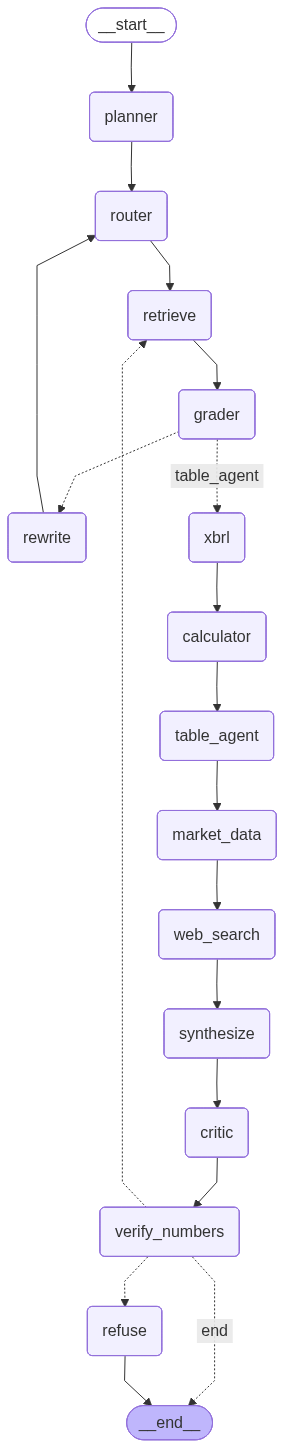

In [25]:
# Render the compiled agent graph as a PNG (needs internet for mermaid.ink).
from finagent.graph.builder import build_graph
from IPython.display import Image, display
graph = build_graph(market="us", provider="groq")
try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception as e:
    print(f"PNG render failed ({type(e).__name__}: {e}); Mermaid source below:\n")
    print(graph.get_graph().draw_mermaid())

**Reading the graph.** `START → planner` splits the question into sub-queries;
`router` labels each (narrative / numeric / market / external); `retrieve` runs
hybrid retrieval; `grader` scores the chunks. The **conditional edge** out of
`grader` goes to `rewrite` (reformulate and loop back through `router`) when
evidence is weak, otherwise on to the tool lanes (`table_agent → market_data →
web_search`). `synthesize` writes the cited draft, `critic` checks claims, and the
conditional edge out of `verify_numbers` either loops back to `retrieve`, ends, or
routes to `refuse` when figures can't be grounded.

### 4.2 Node-by-node walkthrough

Each node reads some state fields, does one job, and writes some fields. This table
is generated from the backend's `NODE_REFERENCE` (one source of truth).

In [4]:
# The node reference table, straight from the backend.
import pandas as pd
from finagent.graph.builder import NODE_REFERENCE
pd.DataFrame(NODE_REFERENCE, columns=["Node", "Reads", "Does", "Writes", "LLM"])

,Node,Reads,Does,Writes,LLM
0,planner,question,Decomposes the question into 1-3 sub-queries,sub_queries,planner (llama-3.1-8b)
1,router,sub_queries,Classifies each sub-query: narrative/numeric/m...,query_routes,planner (llama-3.1-8b)
2,retrieve,sub_queries,Hybrid BM25∪dense retrieval + cross-encoder re...,retrieved_chunks,—
3,grader,retrieved_chunks,Scores each chunk 1-5 for relevance; drops low...,"grades, avg_grade",grader (llama-3.1-8b)
4,rewrite,"question, avg_grade",Reformulates the query when retrieval graded p...,"sub_queries, rewrite_history",planner (llama-3.1-8b)
5,table_agent,numeric sub-queries,Retrieves tables and runs generated pandas cod...,table_results,synth (gpt-oss-120b)
6,market_data,market sub-queries,Calls yfinance tools for live price/valuation,"market_data, charts",planner (llama-3.1-8b)
7,web_search,external/low-confidence sub-queries,Tavily web search (news fallback) for current/...,web_results,—
8,synthesize,"retrieved_chunks, table/web/market results",Writes the cited draft answer from all evidence,"draft_answer, citations",synth (gpt-oss-120b)
9,critic,"draft_answer, retrieved_chunks",Checks every claim against context; may schedu...,"grading_score, needs_retry",critic (gpt-oss-120b)


### 4.3 Full agent trace — example

Run a real comparison question through the whole graph and watch each node fire.
`run_with_trace` streams the compiled graph and captures every node's state change;
`format_trace` renders it.

In [5]:
# Run the full agent and print a readable, node-by-node trace.
# (Heavy: many LLM calls, ~30-90s; needs GROQ_API_KEY.)
from finagent.graph.runner import run_with_trace, format_trace
result = run_with_trace(
    "What was Apple's operating margin in FY2023 compared to FY2022?")
print(format_trace(result))

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Question: What was Apple's operating margin in FY2023 compared to FY2022?

── Planner ─────────────────────────────────────────────────
  sub-queries: What was Apple's operating margin in FY2023?; What was Apple's operating margin in FY2022?

── Router ──────────────────────────────────────────────────
  routes: numeric, numeric

── Retrieve ────────────────────────────────────────────────
  retrieved 7 chunks

── Grader ──────────────────────────────────────────────────
  avg_grade=3.57  kept 4 chunks

── Table Agent ─────────────────────────────────────────────
  2 result(s)

── Market Data ─────────────────────────────────────────────
  0 result(s)

── Web Search ──────────────────────────────────────────────
  0 result(s)

── Synthesize ──────────────────────────────────────────────
  No relevant evidence was found regarding Apple’s operating margin for FY 2023 or FY 2022.…

── Critic ──────────────────────────────────────────────────
  grading_score=1.0  needs_retry=False

── Veri

The trace makes the agent's reasoning auditable: you can see how the question was
decomposed, what was retrieved and graded, whether it rewrote or looped, and how
the critic/verifier signed off before the final answer was returned.

## Section 5 — Tools

The agent routes each sub-query to the cheapest tool that can answer it. Tools that
**exist today** are demonstrated with a real call; tools on the roadmap have a
placeholder noting which phase adds them.

### 5.1 Ticker → CIK Resolver  &nbsp;·&nbsp; ✅ *Phase 2*

Every SEC data API — XBRL company-facts (5.2), the EDGAR submissions/fetch
endpoint (5.4), full-text search (5.5) — keys off the **CIK**, the SEC's
zero-padded 10-digit company identifier, *not* the ticker. So before any of
those tools can run, we need to turn `"AAPL"` **or** `"Apple"` into
`"0000320193"`. That's this resolver — the shared plumbing the rest of Section 5
builds on.

**How it works** (`finagent.tools.resolver.TickerCIKResolver`): it downloads
SEC's published `company_tickers.json` once, caches it on disk
(`data/cache/`, refreshed weekly), and resolves in three tiers —

| tier | example | match field |
|---|---|---|
| exact ticker (case-insensitive) | `AAPL` → Apple | `ticker` |
| exact name (corporate suffixes stripped) | `Apple` → `Apple Inc.` | `name_exact` |
| prefix / fuzzy fallback | `Pepsi` → `PepsiCo`, `Microsft` → `Microsoft` | `name_prefix` / `name_fuzzy` |

This is **infrastructure**, not a behaviour change, so it isn't measured on the
eval (no ledger row). Instead we test it in isolation below: 20 tickers and 20
company names, confirming each resolves to the correct CIK.

In [3]:
# Isolation test: 20 tickers + 20 company names -> correct zero-padded CIK.
import pandas as pd
from finagent.tools.resolver import TickerCIKResolver

resolver = TickerCIKResolver()        # first call downloads + caches company_tickers.json

tickers = {
    "AAPL": "0000320193", "MSFT": "0000789019", "AMZN": "0001018724",
    "GOOGL": "0001652044", "TSLA": "0001318605", "NVDA": "0001045810",
    "JPM": "0000019617", "KO": "0000021344", "XOM": "0000034088",
    "WMT": "0000104169", "JNJ": "0000200406", "PEP": "0000077476",
    "NFLX": "0001065280", "DIS": "0001744489", "BA": "0000012927",
    "INTC": "0000050863", "AMD": "0000002488", "PFE": "0000078003",
    "ORCL": "0001341439", "COST": "0000909832",
}
names = {
    "Apple": "0000320193", "Microsoft": "0000789019", "Amazon": "0001018724",
    "Tesla": "0001318605", "Nvidia": "0001045810", "Coca Cola": "0000021344",
    "JPMorgan": "0000019617", "Walmart": "0000104169", "Microsft": "0000789019",
    "Goldman Sachs": "0000886982", "Berkshire Hathaway": "0001067983",
    "Johnson & Johnson": "0000200406", "Exxon": "0000034088", "Pepsi": "0000077476",
    "Netflix": "0001065280", "Boeing": "0000012927", "Intel": "0000050863",
    "Pfizer": "0000078003", "Oracle": "0001341439", "Costco": "0000909832",
}

def run_cases(cases: dict) -> tuple[pd.DataFrame, int]:
    rows, correct = [], 0
    for query, expected in cases.items():
        res = resolver.resolve(query)
        ok = res["cik"] == expected
        correct += ok
        rows.append({"query": query, "cik": res["cik"], "match": res["match"],
                     "title": res["title"], "ok": "✅" if ok else f"❌ exp {expected}"})
    return pd.DataFrame(rows), correct

t_df, t_ok = run_cases(tickers)
n_df, n_ok = run_cases(names)
print(f"Tickers : {t_ok}/{len(tickers)} correct")
print(f"Names   : {n_ok}/{len(names)} correct")
assert t_ok == len(tickers) and n_ok == len(names), "resolver isolation test failed"
print("✅ Phase 2 isolation test passed — resolver ready as shared infra for 5.2 / 5.4 / 5.5.")
pd.concat([t_df.assign(kind="ticker"), n_df.assign(kind="name")], ignore_index=True)

Tickers : 20/20 correct
Names   : 20/20 correct
✅ Phase 2 isolation test passed — resolver ready as shared infra for 5.2 / 5.4 / 5.5.


,query,cik,match,title,ok,kind
0,AAPL,0000320193,ticker,Apple Inc.,✅,ticker
1,MSFT,0000789019,ticker,MICROSOFT CORP,✅,ticker
2,AMZN,0001018724,ticker,AMAZON COM INC,✅,ticker
3,GOOGL,0001652044,ticker,Alphabet Inc.,✅,ticker
4,TSLA,0001318605,ticker,"Tesla, Inc.",✅,ticker
5,NVDA,0001045810,ticker,NVIDIA CORP,✅,ticker
6,JPM,0000019617,ticker,JPMORGAN CHASE & CO,✅,ticker
7,KO,0000021344,ticker,COCA COLA CO,✅,ticker
8,XOM,0000034088,ticker,EXXON MOBIL CORP,✅,ticker
9,WMT,0000104169,ticker,Walmart Inc.,✅,ticker


### 5.2 XBRL Facts Tool  &nbsp;·&nbsp; ✅ *Phase 3*

This is the **accuracy unlock**. Every US public company files its financials as
**XBRL** — machine-tagged structured data — alongside the 10-K. Instead of
retrieving prose and hoping the synthesizer copies the number correctly, we read
the *exact reported figure* straight from SEC's company-facts API. There is no
LLM in the number path, so there is nothing to hallucinate.

`finagent.tools.xbrl.XBRLClient` does three things:

1. **resolve** the ticker/name → CIK (the Phase-2 resolver), then download +
   disk-cache `data.sec.gov/api/xbrl/companyfacts/CIK{cik}.json`;
2. **pick the right tag** despite *tag heterogeneity* — the same concept is filed
   under different XBRL tags by different companies (`Revenues` vs
   `RevenueFromContractWithCustomerExcludingAssessedTax`). A curated
   concept→tags map handles the common cases; a cheap **LLM fallback** picks from
   the tags a company *actually* reports when the map misses;
3. **select the period** robustly — it derives the fiscal year from each fact's
   period-*end* date (so restated comparatives tagged with the wrong `fy`, and
   52/53-week filers like J&J, still line up), preferring the 10-K full-year value.

It also resolves real-world ambiguities: `Revenues` is the consolidated top line
when present (Walmart's \$572.7B total vs \$567.8B net product sales), and it
skips placeholder-zero tags in favour of a sibling tag that holds the real
figure (J&J files R&D under `...ExcludingAcquiredInProcessCost`).

**Wiring (minimal, per the roadmap):** the router already classifies sub-queries
as `numeric`; those now hit an `xbrl` graph node *before* the table agent. Its
facts become the **highest-priority evidence** the synthesizer cites and the
ground truth the numeric verifier checks against. The principled dispatcher that
routes numeric questions to skip retrieval entirely comes in Phase 7.

In [4]:
# Isolation: exact reported figures straight from SEC XBRL company-facts.
import pandas as pd
from finagent.tools.xbrl import XBRLClient

xbrl = XBRLClient()      # resolver + companyfacts, both disk-cached
cases = [
    ("AAPL", "revenue", "FY2022"), ("MSFT", "total revenue", "FY2022"),
    ("WMT", "total revenue", "FY2022"),   # Revenues (total) vs net sales
    ("PFE", "revenue", "FY2022"),         # total revenues vs product revenue
    ("JNJ", "research and development", "FY2021"),  # tag-heterogeneity (non-zero sibling)
    ("NVDA", "revenue", "FY2022"), ("AMZN", "revenue", "FY2021"),
    ("KO", "net income", "2021"), ("AAPL", "diluted eps", "FY2022"),
    ("MSFT", "total assets", "FY2021"),
]
rows = []
for t, c, p in cases:
    r = xbrl.run(t, c, p)
    rows.append({"ticker": t, "concept": c, "period": p,
                 "value": r.get("value_str") if r["ok"] else f"FAIL: {r.get('error')}",
                 "tag": r.get("tag", ""), "match": r.get("tag_match", ""),
                 "fy": r.get("fy", ""), "form": r.get("form", "")})
pd.DataFrame(rows)

,ticker,concept,period,value,tag,match,fy,form
0,AAPL,revenue,FY2022,"$394,328,000,000",RevenueFromContractWithCustomerExcludingAssess...,concept_map,2022,10-K
1,MSFT,total revenue,FY2022,"$198,270,000,000",RevenueFromContractWithCustomerExcludingAssess...,concept_map,2022,10-K
2,WMT,total revenue,FY2022,"$572,754,000,000",Revenues,concept_map,2022,10-K
3,PFE,revenue,FY2022,"$100,330,000,000",Revenues,concept_map,2022,10-K
4,JNJ,research and development,FY2021,"$14,714,000,000",ResearchAndDevelopmentExpenseExcludingAcquired...,concept_map,2021,10-K
5,NVDA,revenue,FY2022,"$26,914,000,000",Revenues,concept_map,2022,10-K
6,AMZN,revenue,FY2021,"$469,822,000,000",RevenueFromContractWithCustomerExcludingAssess...,concept_map,2021,10-K
7,KO,net income,2021,"$9,771,000,000",NetIncomeLoss,concept_map,2021,10-K
8,AAPL,diluted eps,FY2022,6.11,EarningsPerShareDiluted,concept_map,2022,10-K
9,MSFT,total assets,FY2021,"$333,779,000,000",Assets,concept_map,2021,10-K


In [5]:
# End-to-end: a numeric question now answers from the exact XBRL figure.
# The router sends it to the `numeric` lane -> `xbrl` node -> authoritative [1].
from finagent.api.rag_service import run_agentic

res = run_agentic(market="us", question="What was Apple's total revenue in fiscal year 2022?")
print("routes        :", res["metadata"]["query_routes"])
print("xbrl_facts    :", res["metadata"]["xbrl_facts"], "(exact figures grounded)")
for c in res["chunks"]:
    if c.get("kind") == "xbrl":
        print("XBRL evidence :", c["text"].splitlines()[0], "—", c["citation"])
print("\nAnswer:\n" + res["answer"])

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

routes        : ['numeric']
xbrl_facts    : 1 (exact figures grounded)
XBRL evidence : total revenue (FY2022) = $394,328,000,000 — SEC XBRL companyfacts (us-gaap:RevenueFromContractWithCustomerExcludingAssessedTax, FY2022 10-K, filed 2022-10-28)

Answer:
Apple’s **total revenue for fiscal year 2022 was **$394.328 billion**【1】【2】**. This figure comes from Apple’s 2022 Form 10‑K filing (SEC XBRL data) and is reflected in the company’s reported net sales for that year.


### 5.3 Financial Calculator  &nbsp;·&nbsp; ✅ *Phase 4*

Reported figures answer "what was revenue"; analysts also ask for **derived**
metrics — margins, ratios, growth, CAGR — and a trend across several years. The
calculator computes these *deterministically over exact XBRL inputs* (Section
5.2), never over retrieved prose, so every result is auditable down to the two
filed figures it divided.

`finagent.tools.calculator.FinancialCalculator` (sharing the XBRL client's cache):

| family | metrics | formula |
|---|---|---|
| margins | gross / operating / net margin | line item ÷ revenue |
| ratios | current ratio, debt-to-equity, ROE, ROA, asset turnover, interest coverage | two balance-sheet / income items |
| growth | period-over-period % change | (vₜ − vₜ₋₁) / vₜ₋₁ |
| CAGR | compound annual growth | (v_end / v_start)^(1/n) − 1 |
| trend | any of the above across N periods | per-period series + first→last change |

Every result carries its `inputs` — each input's value, XBRL tag, fiscal year,
and SEC source — so "operating margin 30.3%" is traceable to `operating_income
$119,437M / revenue $394,328M` from Apple's FY2022 10-K.

**Wiring (minimal):** numeric sub-queries pass through a `calculator` graph node
(right after the `xbrl` node). A cheap LLM call decides whether the sub-query
wants a *derived* metric and extracts (ticker, metric, periods); plain
single-figure lookups are left to the XBRL node. Results join XBRL facts as
authoritative evidence for synthesis and numeric verification.

In [7]:
# Isolation: derived metrics computed deterministically from exact XBRL inputs.
import pandas as pd
from finagent.tools.calculator import FinancialCalculator

calc = FinancialCalculator()      # shares the XBRL company-facts cache

# Single-period ratios/margins for Apple FY2022.
rows = []
for m in ["gross_margin", "operating_margin", "net_margin", "current_ratio",
          "return_on_equity", "return_on_assets", "debt_to_equity", "asset_turnover"]:
    r = calc.ratio("AAPL", m, "FY2022")
    rows.append({"metric": m, "value": r.get("value_str") if r["ok"] else r["error"],
                 "formula": r.get("formula", "")})
print("Apple FY2022 derived metrics:")
display(pd.DataFrame(rows))

# Growth + CAGR (each carries its exact inputs).
print("revenue YoY FY2021->FY2022:", calc.growth("AAPL", "revenue", "FY2021", "FY2022")["value_str"])
cg = calc.cagr("AAPL", "revenue", "FY2019", "FY2022")
print(f"revenue CAGR FY2019->FY2022: {cg['value_str']} over {cg['years']}y")

Apple FY2022 derived metrics:


,metric,value,formula
0,gross_margin,43.3%,gross_profit / revenue
1,operating_margin,30.3%,operating_income / revenue
2,net_margin,25.3%,net_income / revenue
3,current_ratio,0.88×,current_assets / current_liabilities
4,return_on_equity,197.0%,net_income / stockholders_equity
5,return_on_assets,28.3%,net_income / total_assets
6,debt_to_equity,5.96×,total_liabilities / stockholders_equity
7,asset_turnover,1.12×,revenue / total_assets


revenue YoY FY2021->FY2022: +7.8%
revenue CAGR FY2019->FY2022: 14.9% over 3y


In [8]:
# Exit-criteria demo: operating margin TREND over 3 years, from XBRL inputs.
calc = FinancialCalculator()
trend = calc.trend("AAPL", "operating_margin", ["FY2020", "FY2021", "FY2022"])

print("Apple operating margin trend (computed from exact XBRL):")
for s in trend["series"]:
    inp = ""  # show the underlying division for full auditability
    r = calc.ratio("AAPL", "operating_margin", s["period"])
    if r["ok"]:
        num, den = r["inputs"]
        inp = f"   = {num['value_str']} / {den['value_str']}"
    print(f"  {s['period']}: {s['value_str']:>7}{inp}")
print("\nSummary:", trend["summary"], "|", trend["change_str"])

Apple operating margin trend (computed from exact XBRL):
  FY2020:   24.1%   = $66,288,000,000 / $274,515,000,000
  FY2021:   29.8%   = $108,949,000,000 / $365,817,000,000
  FY2022:   30.3%   = $119,437,000,000 / $394,328,000,000

Summary: operating margin rose from 24.1% (FY2020) to 30.3% (FY2022) | rose 6.1 pts


In [9]:
# End-to-end: the agent routes this to the `calculator` node and answers from
# the computed series — every figure traceable to filed XBRL inputs.
from finagent.api.rag_service import run_agentic

res = run_agentic(market="us",
                  question="What was Apple's operating margin trend over fiscal years 2020 to 2022?")
print("routes      :", res["metadata"]["query_routes"])
print("calc_results:", res["metadata"]["calc_results"])
for c in res["chunks"]:
    if c.get("kind") == "calc":
        print("  ", c["text"].splitlines()[0])
print("\nAnswer:\n" + res["answer"])

routes      : ['numeric', 'numeric', 'numeric']
calc_results: 1
   AAPL operating margin trend: FY2020=24.1%, FY2021=29.8%, FY2022=30.3% — operating margin rose from 24.1% (FY2020) to 30.3% (FY2022)

Answer:
**Apple’s operating margin improved steadily from FY 2020 through FY 2022**. The margin rose from **24.1 %** in FY 2020 to **29.8 %** in FY 2021 and reached **30.3 %** in FY 2022, indicating a clear upward trajectory in operating efficiency and profitability over the three‑year period【1】.

| Fiscal Year | Operating Margin |
|-------------|-----------------|
| **FY 2020** | **24.1 %** |
| **FY 2021** | **29.8 %** |
| **FY 2022** | **30.3 %** |

- The margin increased **5.7 percentage points** from FY 2020 to FY 2021.  
- It rose an additional **0.5 percentage points** from FY 2021 to FY 2022.  

*Note: These figures are derived from XBRL inputs and should be cross‑checked with Apple’s official filings for absolute precision.*【1】


### 5.4 Dynamic SEC Fetch  &nbsp;·&nbsp; ✅ *Phase 5*

The baseline corpus is ~20 tickers. Rather than pre-index the whole market, the
agent **expands the corpus on demand**: when a question is about a US-listed
company we haven't indexed, it fetches that company's latest 10-K from EDGAR,
runs it through the *same* ingestion pipeline (parse → chunk → embed → store)
into the live collection, and then retrieves — so it can answer a question it
couldn't a moment earlier.

`finagent.tools.sec_fetch.SecFilingFetcher` provides the **corpus-membership
gate**, a cheap three-way decision:

| gate decision | condition | action |
|---|---|---|
| `already_indexed` | a chunk with that ticker exists in Chroma | retrieve as usual |
| `fetch` | resolver returns a CIK (US-listed) **and** not indexed | fetch + ingest, then retrieve |
| `not_us_listed` | resolver finds no CIK | leave to the web-search branch |

The first test is a Chroma metadata query (`where ticker=…`, limit 1); the
US-listed test reuses the Phase-2 resolver (a CIK ⇒ SEC-registered).

**Wiring:** a `fetch_filing` graph node sits between routing and retrieval. On a
`fetch` decision it ingests the 10-K and **invalidates the cached hybrid
retrievers** so the new chunks are searchable on the same turn, and surfaces a
"Fetching latest 10-K…" status to the UI.

> 💡 *Persistence:* locally this writes straight to on-disk Chroma and survives
> across runs. On Cloud Run's scale-to-zero those runtime-added chunks are lost
> when the instance recycles — a deploy-time problem handled in **Phase 12**, not
> here.

In [14]:
# The corpus-membership gate: three-way decision, no LLM needed.
import pandas as pd
from finagent.tools.sec_fetch import SecFilingFetcher

fetcher = SecFilingFetcher(collection_name=CORPUS_COLLECTION, chroma_dir=CHROMA_DIR)
rows = []
for q in ["AAPL", "Microsoft", "CRM", "Uber", "Palantir", "Reliance Industries", "Toyota"]:
    g = fetcher.gate(q)
    rows.append({"query": q, "decision": g["decision"],
                 "ticker": g["ticker"], "cik": g["cik"], "company": g["company"]})
pd.DataFrame(rows)

,query,decision,ticker,cik,company
0,AAPL,already_indexed,AAPL,0000320193,Apple Inc.
1,Microsoft,already_indexed,MSFT,0000789019,MICROSOFT CORP
2,CRM,already_indexed,CRM,0001108524,"Salesforce, Inc."
3,Uber,fetch,UBER,0001543151,"Uber Technologies, Inc"
4,Palantir,fetch,PLTR,0001321655,Palantir Technologies Inc.
5,Reliance Industries,not_us_listed,NaN,NaN,NaN
6,Toyota,fetch,TM,0001094517,TOYOTA MOTOR CORP/


In [15]:
# Live demo: fetch + ingest a fresh ticker not in the baseline corpus.
# (Network + embed; ~20-30s. Pick a US ticker you haven't fetched yet.)
TICKER = "UBER"
print("before:", fetcher.gate(TICKER)["decision"])
res = fetcher.run(TICKER, n=1)        # gate -> fetch latest 10-K -> ingest
print(f"status      : {res['status']}")
print(f"chunks added: {res.get('chunks_added')}  (fiscal years: {res.get('years')})")
print(f"source      : {res.get('source_urls')}")
print("after :", fetcher.gate(TICKER)["decision"], "— now searchable in the live corpus")

before: fetch


from_sec: 100%|██████████| 1/1 [00:02<00:00,  2.20s/it]



Downloaded: 1/1
Found 1 records to consider
Found 68 already-indexed sources


ingest [us]: 100%|██████████| 1/1 [00:09<00:00,  9.04s/it]


Ingestion complete
  Files processed: 1
  Files skipped:   0
  Files failed:    0
  Total chunks:    443
  Duration:        10.9s
status      : fetched
chunks added: 443  (fiscal years: ['2026'])
source      : ['https://www.sec.gov/Archives/edgar/data/000154315126000015/primary-document.html']
after : already_indexed — now searchable in the live corpus


In [ ]:
# End-to-end: the agent fetches a missing company mid-run, then answers from it.
# (Heavy: fetch + ingest + full agent. The `fetch_filing` node reports its work.)
# from finagent.api.rag_service import run_agentic

res = run_agentic(market="us",
                  question="What does Uber describe as its principal business segments in its latest 10-K?")
fs = res["metadata"].get("fetch_status") or {}
print("fetch decision:", fs.get("decision"), "| status:", fs.get("status"),
      "| chunks added:", fs.get("chunks_added"))
print("\nAnswer:\n" + res["answer"])

fetch decision: None | status: None | chunks added: None

Answer:
**Overview**  
In its most recent Form 10‑K, Uber describes its operations as being organized around three principal business segments: **Mobility**, **Delivery**, and **Freight** — each built on its technology platform that connects end‑users with independent providers [1].

**Principal segments**

- **Mobility** – ridesharing services that link Riders with independent Mobility Drivers to move from point A to point B [1].  
- **Delivery** – food, grocery and other merchant deliveries that connect Riders/Eaters with Couriers who pick up orders from Restaurants, Grocers or Stores [1].  
- **Freight** – logistics services that match Shippers with Carrier partners to book shipments and manage transportation [1].  


### 5.5 EDGAR Full-Text Search  &nbsp;·&nbsp; ✅ *Phase 6*

Every tool so far answers questions about *one* company. But some questions are
inherently **cross-document**: "which companies disclosed a material weakness?",
"list firms that mention quantum computing in their 10-K". The answer is a *set
of companies*, and no amount of single-company chunk retrieval can produce it —
you have to search the full text of *many* companies' filings at once.

`finagent.tools.edgar_search.EdgarFullTextSearch` wraps SEC's EDGAR full-text
search (`efts.sec.gov`, covering filings since 2001). Given a phrase it returns
the **distinct companies** whose filings match (most-recent filing each), with a
direct link to every filing. It's HTTP-only — no embeddings — with a small
retry/backoff since EDGAR is rate-sensitive.

**Wiring:** the router gains a fifth lane, `cross_document`, for "which
companies…" questions. Those sub-queries hit an `edgar_search` graph node that
extracts the search phrase (falling back from an exact-phrase to an all-words
match if the phrase is over-qualified) and defaults to a recent date window so
the answer is current filers, not decade-old hits.

In [18]:
# Isolation: cross-document search — the SET of companies matching a phrase.
import pandas as pd
from finagent.tools.edgar_search import EdgarFullTextSearch

edgar = EdgarFullTextSearch()
r = edgar.run('"material weakness in internal control over financial reporting"',
              forms="10-K", n=8, startdt="2023-06-01", enddt="2024-12-31")
print(f'phrase: {r["query"]}  |  ~{r["total"]:,} matching filings  |  {r["n_companies"]} companies shown')
pd.DataFrame(r["companies"])[["company", "ticker", "form", "date", "url"]]

phrase: "material weakness in internal control over financial reporting"  |  ~448 matching filings  |  8 companies shown


,company,ticker,form,date,url
0,OPTICAL CABLE CORP,OCC,10-K,2024-12-23,https://www.sec.gov/Archives/edgar/data/100023...
1,HP INC,HPQ,10-K,2024-12-13,https://www.sec.gov/Archives/edgar/data/47217/...
2,VALVOLINE INC,VVV,10-K,2024-11-22,https://www.sec.gov/Archives/edgar/data/167491...
3,"World Scan Project, Inc.",WDSP,10-K,2024-11-19,https://www.sec.gov/Archives/edgar/data/181374...
4,"Spyre Therapeutics, Inc.",SYRE,10-K/A,2024-11-18,https://www.sec.gov/Archives/edgar/data/163628...
5,Vanguard Green Investment Ltd,VGES,10-K,2024-11-12,https://www.sec.gov/Archives/edgar/data/174611...
6,FACTSET RESEARCH SYSTEMS INC,FDS,10-K,2024-10-29,https://www.sec.gov/Archives/edgar/data/101323...
7,Rise Gold Corp.,RYES,10-K,2024-10-29,https://www.sec.gov/Archives/edgar/data/142486...


In [19]:
# End-to-end: a "which companies…" question routes to the `cross_document`
# lane and is answered from EDGAR. (Heavy: loads the agent + one LLM call + FTS.)
from finagent.api.rag_service import run_agentic

res = run_agentic(market="us",
                  question="Which companies disclosed a going concern doubt in their recent 10-K?")
print("routes         :", res["metadata"]["query_routes"])
print("edgar companies:", res["metadata"]["edgar_companies"])
for c in [c for c in res["chunks"] if c.get("kind") == "edgar"][:6]:
    print("  ", c["text"][:90])
print("\nAnswer:\n" + res["answer"][:600])

routes         : ['cross_document']
edgar companies: 0

Answer:
No information is available.


### 5.6 yfinance (live market data)

**What it is.** Live price, valuation, and company-info lookups via Yahoo Finance.
The agent calls it for *current* market questions (price, market cap, P/E) — not
historical financials, which come from filings/XBRL.

In [24]:
# Sample call — a live quote for one symbol. (Needs network.)
from finagent.graph.market_tools import get_quote
get_quote("DPRO")

{'ok': True,
 'data': {'lastPrice': 7.230100154876709,
  'previousClose': 6.92,
  'open': 6.900000095367432,
  'dayHigh': 7.309999942779541,
  'dayLow': 6.669000148773193,
  'currency': 'USD',
  'marketCap': 263869294.21627092,
  'yearHigh': 14.399999618530273,
  'yearLow': 2.0799999237060547,
  'yearChange': 1.8765430366618103,
  'fiftyDayAverage': 5.705199975967407,
  'twoHundredDayAverage': 7.042324998378754,
  'lastVolume': 1585281,
  'symbol': 'DPRO'},
 'error': None}

In [7]:
# Sample call — company info / valuation snapshot.
from finagent.graph.market_tools import get_company_info
get_company_info("AAPL")

{'ok': True,
 'data': {'symbol': 'AAPL',
  'long_name': 'Apple Inc.',
  'sector': 'Technology',
  'industry': 'Consumer Electronics',
  'country': 'United States',
  'website': 'https://www.apple.com',
  'employees': 166000,
  'summary': 'Apple Inc. designs, manufactures, and markets smartphones, personal computers, tablets, wearables, and accessories worldwide. The company offers iPhone, a line of smartphones; Mac, a line of personal computers; iPad, a line of multi-purpose tablets; and wearables, home, and accessories comprising AirPods, Apple Vision Pro, Apple TV, Apple Watch, Beats products, and HomePod, as well as Apple branded and third-party accessories. It also provides AppleCare support and cloud services; and operates various platforms, including the App Store that allow customers to discover and download applications and digital content, such as books, music, video, games, and podcasts, as well as advertising services include third-party licensing arrangements and its own ad

The agent's `market_data` node wraps these via `call_tool(...)` and attaches the
results (and any chart specs) to the answer's evidence panel.

### 5.7 Tavily web search (news + non-corpus fallback)

**What it is.** Trusted-domain web search via Tavily, with a local news-collection
fallback. Used for (1) current events the 10-K doesn't cover, (2) companies not in
the corpus, and (3) India-market questions.

In [8]:
# Sample call — search recent financial news. (Needs TAVILY_API_KEY or local news.)
from finagent.graph.web_search import WebSearcher
hits = WebSearcher().search("Apple supply chain news 2024", k=3)
for h in hits:
    print(f"[{h.get('source','web')}] {h.get('title','')[:80]}")
    print(f"   {(h.get('content') or '')[:140]}...")
print(f"\n(showing {len(hits)} hits)")

[tavily] Apple Intel Chip Pact Adds New Angle To Supply Chain Story
   * Apple and Intel have reached a preliminary chip manufacturing agreement that would shift part of Apple's processor production to Intel fac...
[tavily] India to assemble 28% of global iPhones in 2026 as Apple deepens supply chain sh
   # India to assemble 28% of global iPhones in 2026 as Apple deepens supply chain shift beyond China. According to estimates by Smart Analytic...
[tavily] A New Supply Chain Focus for Apple Under CEO John Ternus | Supply Chain Digital
   # A New Supply Chain Focus for Apple Under CEO John Ternus. John Ternus, Apple's CEO (Credit: Apple). John Ternus is taking over as Apple's ...

(showing 3 hits)


The `web_search` node escalates to this automatically when filing retrieval comes
back empty or weakly graded, so out-of-corpus questions get an answer instead of
"no information".

## Section 6 — Query Routing: How the Agent Decides

The router classifies each sub-query and sends it to the right lane. Today's lanes
are **narrative / numeric / market / external**; XBRL, calculator, dynamic-fetch,
and full-text lanes arrive in Phases 3–6.

| Query type | Signal words | Routed to | Status |
|---|---|---|---|
| Narrative | "how did", "explain", "strategy" | Retrieval | ✅ today |
| Numeric (table) | "what was", a specific year, dollar amounts | Table agent | ✅ today |
| Market / live | "price", "market cap", "today" | yfinance | ✅ today |
| Current / news | "latest", "recently", "this week" | Web search | ✅ today |
| Out-of-corpus / India | company not indexed | Web search | ✅ today |
| Numeric fact | exact reported line item | XBRL | 🚧 Phase 3 |
| Derived metric | "margin", "growth", "CAGR" | Calculator | 🚧 Phase 4 |
| Unknown US ticker | not indexed | Dynamic fetch | 🚧 Phase 5 |
| Cross-document | "which companies", "across the sector" | Full-text | 🚧 Phase 6 |

In [9]:
# Show the routing decision (planner + router only — 2 LLM calls each) per query.
from finagent.graph.runner import run_with_route_trace
queries = [
    "What did Apple's management say about services growth?",   # narrative
    "What was Apple's gross profit in FY2023?",                 # numeric
    "What is Apple's current stock price and market cap?",      # market
    "What is the latest news on Apple's supply chain?",         # current/web
]
for q in queries:
    r = run_with_route_trace(q)
    print(f"Q: {q}")
    print(f"   sub-queries: {r['sub_queries']}")
    print(f"   → routes: {r['routes']}\n")

Q: What did Apple's management say about services growth?
   sub-queries: ["What did Apple's management say about services growth?"]
   → routes: ['narrative']

Q: What was Apple's gross profit in FY2023?
   sub-queries: ["What was Apple's gross profit in FY2023?"]
   → routes: ['numeric']

Q: What is Apple's current stock price and market cap?
   sub-queries: ["What is Apple's current stock price?", "What is Apple's market cap?"]
   → routes: ['market', 'numeric']

Q: What is the latest news on Apple's supply chain?
   sub-queries: ["What is the latest news on Apple's supply chain?"]
   → routes: ['external']



Routing is per-sub-query, so a compound question can fan out across several lanes
at once. The router's choices are what keep cost down — a numeric lookup shouldn't
pay for narrative retrieval, and vice-versa.

## Section 7 — Multi-hop: Sub-query Decomposition

Comparison questions need several facts gathered independently, then combined. The
planner decomposes them; each sub-query is routed and resolved on its own; the
synthesizer aggregates.

In [10]:
# Run a multi-hop comparison end-to-end and show the decomposition + answer.
# (Heavy: full agent run, ~60-120s.)
from finagent.graph.runner import run_with_full_trace
result = run_with_full_trace(
    "Compare Apple and Microsoft's R&D spend as a percentage of revenue over the "
    "last three years and explain the trend.")
print("Sub-queries (planner decomposition):")
for i, sq in enumerate(result["sub_queries"], 1):
    print(f"  {i}. {sq}")
print("\nRoutes:", result["routes"])
print("\nFinal answer:\n", result["final_answer"])

Sub-queries (planner decomposition):
  1. supporting evidence for: These expense areas indicate ongoing, sizable R&D investment.
  2. supporting evidence for: Microsoft’s emphasis on cloud and AI platforms suggests that R&D spending is being scaled to sustain rapid growth in those segments.
  3. supporting evidence for: Both firms are clearly increasing R&D outlays.

Routes: ['numeric', 'numeric']

Final answer:
 **Overview**  
Apple’s research‑and‑development (R&D) outlays have risen sharply from 2022 to 2026, while comparable percentage‑of‑revenue data for Microsoft is not available in the provided sources, preventing a direct three‑year comparative analysis.

### Apple R&D Spend (2022‑2026)

- **2022:** $7.7 billion (flat vs. prior year)  
- **2023:** $7.7 billion (‑0.17%)  
- **2024:** $8.3 billion (+7.43%)  
- **2025:** $10.9 billion (+31.68%)  
- **2026 (Q1):** $11.4 billion (+4.89% YoY)  

These figures show a **steady acceleration**, especially from 2024 onward, driven by large

```
Original question
       │ (Planner)
       ▼
  ┌────────────────────────────────────────────────┐
  │ sub-query 1..k:  Apple R&D / revenue per year   │
  │ sub-query k+1..: Microsoft R&D / revenue / year │
  │ + a trend-explanation sub-query (narrative)     │
  └────────────────────────────────────────────────┘
       │ (each routed & retrieved independently)
       ▼ (Synthesizer aggregates)
  Final answer with inline citations
```

Each figure in the answer traces back to a specific filing, and the trend
sentence is grounded in the narrative sub-query — multi-hop without losing
provenance.

## Section 8 — Evaluation

How we measure the system: the FinanceBench dataset, a **decomposed retrieval
eval** (pool recall vs rerank), and the **RAGAS answer eval** — all reported with
per-question-type breakdowns.

### 8.1 Eval dataset

**FinanceBench** is a benchmark of real questions over public-company 10-Ks, each
with a verified answer and the evidence span that supports it. We tag every
question by type (numeric / narrative / comparison) so wins can be attributed to a
specific capability.

In [10]:
# Load FinanceBench, tagged by question type, and show the distribution.
from finagent.evaluation.dataset import load_eval_dataset
df = load_eval_dataset(EVAL_PATH)
print(df["qtype"].value_counts().to_string())
print(f"\nTotal: {len(df)} questions across {df['company'].nunique()} companies")

qtype
numeric       71
narrative     57
comparison    22

Total: 150 questions across 32 companies


In [11]:
# A sample of 5 questions (answer truncated for readability).
sample = df[["question", "company", "qtype", "answer"]].head(5).copy()
sample["answer"] = sample["answer"].str.slice(0, 80)
sample

,question,company,qtype,answer
0,What is the FY2018 capital expenditure amount ...,3M,numeric,$1577.00
1,Assume that you are a public equities analyst....,3M,numeric,$8.70
2,Is 3M a capital-intensive business based on FY...,3M,numeric,"No, the company is managing its CAPEX and Fixe..."
3,What drove operating margin change as of FY202...,3M,numeric,Operating Margin for 3M in FY2022 has decrease...
4,"If we exclude the impact of M&A, which segment...",3M,comparison,The consumer segment shrunk by 0.9% organically.


> 💡 FinanceBench's open-source split has no true **cross-document** questions
> (multi-evidence questions cite multiple pages of the *same* filing). That bucket
> stays empty until Phase 6 adds cross-doc questions of our own.

### 8.2 Retrieval evaluation

First index the eval filings into the isolated `financebench_eval` collection
(one-time, ~few minutes), then run the decomposed eval: **`pool_recall@{20,50,100}`**
(did the gold chunk reach the pool?) and **conditional `Hit@{1,3,5}`/`MRR`** (given
it did, did the reranker surface it?).

In [ ]:
# One-time: index the FinanceBench filings into financebench_eval (idempotent).
from finagent.evaluation.financebench import index_eval_corpus
index_eval_corpus()

In [ ]:
# Run the decomposed retrieval eval; show metrics overall and per question type.
from finagent.evaluation.retrieval import run_retrieval_eval, retrieval_result_frame
ret_result = run_retrieval_eval(eval_dataset=df, collection=EVAL_COLLECTION,
                                chroma_dir=CHROMA_DIR)
retrieval_result_frame(ret_result)

Read these two stages together: low **pool recall** is a first-stage problem (fix
retrieval breadth); high pool recall but low **Hit@1** is a reranker problem. The
per-type rows show where the system is weakest today — typically numeric questions,
which Phase 3's XBRL tool targets.

### 8.3 RAGAS answer evaluation

`run_ragas_eval` runs the production agent over a held-out 50-question slice and
scores the answers on **faithfulness, answer relevancy, context precision, and
context recall** — with a judge LLM distinct from the generator.

In [ ]:
# Run the agent over a held-out slice and RAGAS-score it. (Heavy: many LLM calls.)
from finagent.evaluation.dataset import split_heldout
from finagent.evaluation.ragas_eval import run_ragas_eval, ragas_frame
_, heldout = split_heldout(df, n_heldout=50)
ragas_scores = run_ragas_eval(heldout, judge_provider="groq")
ragas_frame(ragas_scores)

Faithfulness is the metric that matters most for a financial agent: it measures
whether the answer's claims are actually grounded in the retrieved evidence. The
per-type breakdown is the honest scorecard each later phase has to beat.

## Section 9 — Results Ledger (grows over time)

The append-only answer to *"is the system getting better?"* — one row per phase
with its full config and every metric. Updated at the end of every phase.

### 9.1 Record this run and display the ledger

Record the current measurement as `baseline_v0` (retrieval + RAGAS, overall and
per type), then display the whole ledger with metrics shaded green→red.

In [ ]:
# Compose the metric payload and append one ledger row for this run.
from finagent.evaluation.ledger import append_row, style_ledger
retrieval_metrics = ret_result.as_dict()
retrieval_metrics["by_type"] = ret_result.by_type
append_row(
    "baseline_v0",
    config={"collection": EVAL_COLLECTION, "embedding": "bge-small-en-v1.5",
            "reranker": "bge-reranker-base", "agent": "AgenticRAGv4"},
    metrics={"retrieval": retrieval_metrics, "ragas": ragas_scores},
    notes=f"pool_recall@100={ret_result.pool_recall.get(100,0):.0%}; "
          f"faithfulness={ragas_scores['overall'].get('faithfulness',0):.2f}",
    ledger_path=LEDGER_PATH,
)
style_ledger(ledger_path=LEDGER_PATH)

### 9.2 Metric progression chart

One line per metric across phases. With only `baseline_v0` recorded it's a single
point per metric; as later phases append rows, this chart tells the improvement
story at a glance.

In [ ]:
# Plot how the headline metrics move across phases.
from finagent.evaluation.ledger import plot_metrics
plot_metrics(
    metrics=["ragas.overall.faithfulness", "ragas.overall.answer_relevancy",
             "ragas.overall.context_recall", "retrieval.hit@3"],
    ledger_path=LEDGER_PATH,
)

Each future phase adds one row and this chart redraws automatically. By Phase 7
it should show a clear upward bend at Phase 3 (XBRL) and Phase 7 (dispatcher) —
the two changes expected to move accuracy most.

## Phase 1 — Make it US-only

**Change (one change, one measurement):** active retrieval now searches the
`us_filings` corpus **only** — `india_filings` was dropped from the live pool in
`finagent/api/rag_service.py`. FinanceBench is a US benchmark, so the India
corpus only added off-market noise to the candidate pool and maintenance burden.

**Why this is safe.** The agent's `web_search_node` already escalates to the web
whenever filing retrieval comes back empty or weakly graded. So any **non-US or
non-corpus** company (e.g. an India-listed firm) now produces empty filing
retrieval and *falls through to the web-search branch* with a graceful
"searched the web instead" answer — instead of surfacing irrelevant Indian
annual-report chunks.

**Expected result:** retrieval metrics are computed against the isolated
`financebench_eval` collection and are therefore **unchanged**; RAGAS answer
quality should be **unchanged or slightly cleaner** (no off-market chunks
diluting the synthesis context). We record this as the `phase1_us_only` ledger
row and read the delta vs `baseline_v0`.

In [ ]:
# Demo: an India-listed company now falls through to the web branch (graceful),
# rather than returning off-market annual-report chunks. (Needs network / Tavily
# or local `news` collection; a few LLM calls.)
from finagent.api.rag_service import run_agentic, health

print("Active retrieval collections:", health()["collections"])  # -> ['us_filings']

india_q = "What was Tata Consultancy Services' total revenue in its latest annual report?"
res = run_agentic(market="us", question=india_q, top_k=5)

text_chunks = [c for c in res["chunks"] if c.get("kind") == "text"]
web_chunks  = [c for c in res["chunks"] if c.get("kind") == "web"]
print(f"\nQ: {india_q}")
print(f"filing chunks used : {len(text_chunks)}  (expected ~0 — TCS not in us_filings)")
print(f"web hits           : {res['metadata'].get('web_hits', 0)}  (escalated to web)")
print(f"\nAnswer:\n{res['answer'][:600]}")

In [ ]:
# Re-run the eval and record `phase1_us_only`, then show the delta vs baseline.
# Retrieval runs against the isolated financebench_eval collection (US-only data),
# so its numbers are unchanged; RAGAS re-runs the now-US-only production agent.
# (Heavy: many LLM calls — reuses `df` and `heldout` from Section 8.)
from finagent.evaluation.retrieval import run_retrieval_eval
from finagent.evaluation.ragas_eval import run_ragas_eval
from finagent.evaluation.ledger import append_row, load_ledger, style_ledger

ret_p1 = run_retrieval_eval(eval_dataset=df, collection=EVAL_COLLECTION, chroma_dir=CHROMA_DIR)
ragas_p1 = run_ragas_eval(heldout, judge_provider="groq")

retrieval_metrics = ret_p1.as_dict()
retrieval_metrics["by_type"] = ret_p1.by_type
append_row(
    "phase1_us_only",
    config={"collection": EVAL_COLLECTION, "embedding": "bge-small-en-v1.5",
            "reranker": "bge-reranker-base", "agent": "AgenticRAGv4",
            "active_collections": ["us_filings"]},
    metrics={"retrieval": retrieval_metrics, "ragas": ragas_p1},
    notes="dropped india_filings from active retrieval; non-US falls through to web. "
          f"pool_recall@100={ret_p1.pool_recall.get(100,0):.0%}; "
          f"faithfulness={ragas_p1['overall'].get('faithfulness',0):.2f}",
    ledger_path=LEDGER_PATH,
)

# Delta vs baseline on the headline metric (faithfulness should hold or improve).
led = load_ledger(LEDGER_PATH)
col = "ragas.overall.faithfulness"
if col in led.columns and {"baseline_v0", "phase1_us_only"} <= set(led["phase"]):
    base = float(led.loc[led["phase"] == "baseline_v0", col].iloc[-1])
    now  = float(led.loc[led["phase"] == "phase1_us_only", col].iloc[-1])
    print(f"faithfulness  baseline_v0={base:.3f}  ->  phase1_us_only={now:.3f}  (Δ {now-base:+.3f})")

style_ledger(ledger_path=LEDGER_PATH)

## Phase 3 — XBRL facts (numeric accuracy unlock)

**Change:** numeric sub-queries are now answered from exact SEC XBRL figures
(Section 5.2) instead of retrieved prose. We re-run the eval and record
`phase3_xbrl`, watching the **numeric** question subset specifically — that's
where the jump should land. We also watch **faithfulness on numeric questions**:
because the figure now comes from a structured source, ungrounded-number
hallucinations should drop.

The retrieval metrics (computed on the isolated `financebench_eval` collection)
are unchanged — XBRL changes *answering*, not *retrieval*. So read the RAGAS
per-type row, not the retrieval row, for this phase's signal.

In [ ]:
# Re-run RAGAS through the now-XBRL-grounded agent; record `phase3_xbrl`.
# (Heavy: many LLM calls. Reuses `df`, `heldout`, `ret_p1` from earlier.)
from finagent.evaluation.retrieval import run_retrieval_eval
from finagent.evaluation.ragas_eval import run_ragas_eval, ragas_frame
from finagent.evaluation.ledger import append_row, load_ledger, style_ledger

ragas_p3 = run_ragas_eval(heldout, judge_provider="groq")
ret_p3 = run_retrieval_eval(eval_dataset=df, collection=EVAL_COLLECTION, chroma_dir=CHROMA_DIR)

retrieval_metrics = ret_p3.as_dict()
retrieval_metrics["by_type"] = ret_p3.by_type
append_row(
    "phase3_xbrl",
    config={"collection": EVAL_COLLECTION, "embedding": "bge-small-en-v1.5",
            "reranker": "bge-reranker-base", "agent": "AgenticRAGv4",
            "numeric_source": "SEC XBRL company-facts"},
    metrics={"retrieval": retrieval_metrics, "ragas": ragas_p3},
    notes="numeric questions answered from exact XBRL facts (us-gaap company-facts); "
          f"numeric faithfulness={ragas_p3.get('by_type',{}).get('numeric',{}).get('faithfulness',float('nan')):.2f}",
    ledger_path=LEDGER_PATH,
)

# Numeric-subset delta vs baseline — the headline for this phase.
print("RAGAS by question type (phase3_xbrl):")
display(ragas_frame(ragas_p3))

led = load_ledger(LEDGER_PATH)
for metric in ("ragas.by_type.numeric.faithfulness", "ragas.by_type.numeric.answer_relevancy"):
    if metric in led.columns and {"baseline_v0", "phase3_xbrl"} <= set(led["phase"]):
        base = float(led.loc[led["phase"] == "baseline_v0", metric].iloc[-1])
        now  = float(led.loc[led["phase"] == "phase3_xbrl", metric].iloc[-1])
        print(f"{metric.split('.')[-1]:18} (numeric)  baseline={base:.3f} -> phase3={now:.3f}  (Δ {now-base:+.3f})")

style_ledger(ledger_path=LEDGER_PATH)

## Phase 4 — Financial calculator (derived metrics)

**Change:** derived-metric questions (margins, ratios, growth, CAGR, trends) are
now computed deterministically over exact XBRL inputs (Section 5.3) instead of
being read out of prose or table text. We re-run the eval and record
`phase4_calc`, watching the **derived-metric** questions — a subset of the
numeric / comparison buckets. As in Phase 3, retrieval metrics are unchanged
(this changes *answering*, not *retrieval*); read the RAGAS per-type row.

In [ ]:
# Re-run RAGAS through the calculator-equipped agent; record `phase4_calc`.
# (Heavy: many LLM calls. Reuses `df`, `heldout` from earlier.)
from finagent.evaluation.retrieval import run_retrieval_eval
from finagent.evaluation.ragas_eval import run_ragas_eval, ragas_frame
from finagent.evaluation.ledger import append_row, load_ledger, style_ledger

ragas_p4 = run_ragas_eval(heldout, judge_provider="groq")
ret_p4 = run_retrieval_eval(eval_dataset=df, collection=EVAL_COLLECTION, chroma_dir=CHROMA_DIR)

retrieval_metrics = ret_p4.as_dict()
retrieval_metrics["by_type"] = ret_p4.by_type
append_row(
    "phase4_calc",
    config={"collection": EVAL_COLLECTION, "embedding": "bge-small-en-v1.5",
            "reranker": "bge-reranker-base", "agent": "AgenticRAGv4",
            "derived_metrics": "FinancialCalculator over XBRL"},
    metrics={"retrieval": retrieval_metrics, "ragas": ragas_p4},
    notes="derived metrics (margins/ratios/growth/CAGR) computed from exact XBRL inputs; "
          f"numeric faithfulness={ragas_p4.get('by_type',{}).get('numeric',{}).get('faithfulness',float('nan')):.2f}",
    ledger_path=LEDGER_PATH,
)

print("RAGAS by question type (phase4_calc):")
display(ragas_frame(ragas_p4))

led = load_ledger(LEDGER_PATH)
for metric in ("ragas.by_type.numeric.faithfulness", "ragas.by_type.comparison.faithfulness"):
    if metric in led.columns and {"phase3_xbrl", "phase4_calc"} <= set(led["phase"]):
        prev = float(led.loc[led["phase"] == "phase3_xbrl", metric].iloc[-1])
        now  = float(led.loc[led["phase"] == "phase4_calc", metric].iloc[-1])
        bucket = metric.split(".")[2]
        print(f"faithfulness ({bucket})  phase3={prev:.3f} -> phase4={now:.3f}  (Δ {now-prev:+.3f})")

style_ledger(ledger_path=LEDGER_PATH)

## Phase 5 — Dynamic SEC fetch (self-expanding corpus)

**Change:** the agent now fetches + ingests a missing US company's 10-K on
demand (Section 5.4), so it can answer questions about tickers outside the
baseline corpus. The right metric here isn't RAGAS faithfulness on FinanceBench
(those companies are already indexed) — it's **out-of-corpus answerable-rate**:
given questions about tickers *deliberately not* in the baseline corpus, how many
does the agent now answer from a freshly-fetched filing instead of refusing?

We measure on a small hand-built set and record `phase5_dynamic_fetch`. Before
Phase 5 the answerable-rate on these was ~0 (refuse / "not in the filings");
after, it should be high.

In [ ]:
# Out-of-corpus answerable-rate on tickers NOT in the baseline corpus.
# (Heavy: each question may fetch + ingest a 10-K, then run the full agent.)
import pandas as pd
from finagent.api.rag_service import run_agentic
from finagent.evaluation.ledger import append_row, style_ledger

# US-listed companies outside the ~20-ticker baseline corpus.
ooc_questions = [
    ("CRM",  "What does Salesforce list as its primary revenue sources in its latest 10-K?"),
    ("UBER", "What are Uber's main operating segments according to its latest 10-K?"),
    ("ABNB", "How does Airbnb describe its business model in its latest 10-K?"),
    ("COIN", "What principal risks does Coinbase disclose in its latest 10-K?"),
    ("PLTR", "What does Palantir describe as its two main software platforms?"),
]

rows, answerable = [], 0
for ticker, q in ooc_questions:
    res = run_agentic(market="us", question=q)
    md = res["metadata"]
    refused = md.get("refused", False)
    # "answerable" = not refused AND grounded in at least one filing chunk.
    grounded = any(c.get("kind") in ("text", "xbrl") for c in res["chunks"])
    ok = (not refused) and grounded
    answerable += ok
    fs = md.get("fetch_status") or {}
    rows.append({"ticker": ticker, "fetch": fs.get("status") or fs.get("decision"),
                 "chunks": fs.get("chunks_added"), "refused": refused,
                 "answerable": "✅" if ok else "❌"})

rate = answerable / len(ooc_questions)
print(f"Out-of-corpus answerable-rate: {answerable}/{len(ooc_questions)} = {rate:.0%}")
display(pd.DataFrame(rows))

append_row(
    "phase5_dynamic_fetch",
    config={"collection": CORPUS_COLLECTION, "agent": "AgenticRAGv4",
            "feature": "dynamic SEC 10-K fetch + ingest", "n_ooc_questions": len(ooc_questions)},
    metrics={"coverage": {"ooc_answerable_rate": round(rate, 3),
                          "ooc_answered": answerable, "ooc_total": len(ooc_questions)}},
    notes=f"out-of-corpus answerable-rate {answerable}/{len(ooc_questions)} via on-demand 10-K fetch",
    ledger_path=LEDGER_PATH,
)
style_ledger(ledger_path=LEDGER_PATH)

## Phase 6 — EDGAR full-text search (cross-document)

**Change:** the agent can now answer **cross-document** questions ("which
companies disclosed X") via EDGAR full-text search (Section 5.5) — a class
single-company chunk retrieval structurally cannot serve. FinanceBench has no
true cross-document questions, so we measure on a **hand-built set of 10**
cross-doc questions and record `phase6_fulltext`.

Metric: **cross-doc answerable-rate** — the fraction of questions for which the
agent routed to `cross_document` and returned at least one matching company.
Before Phase 6 this was 0 (no tool could serve them).

In [ ]:
# Cross-document answerable-rate on 10 hand-crafted "which companies…" questions.
# (Heavy: each runs the full agent; EDGAR is rate-sensitive, so they go serially.)
import pandas as pd
from finagent.api.rag_service import run_agentic
from finagent.evaluation.ledger import append_row, style_ledger

crossdoc_questions = [
    "Which companies disclosed a material weakness in internal control over financial reporting?",
    "Which companies mention quantum computing in their 10-K?",
    "Which companies disclosed a going concern doubt in their recent 10-K?",
    "List companies that reported a cybersecurity incident in their 10-K.",
    "Which firms describe themselves as a clinical-stage biopharmaceutical company?",
    "Which companies mention generative artificial intelligence as a risk factor?",
    "What companies disclosed a restatement of previously issued financial statements?",
    "Which companies reference the CHIPS Act in their 10-K?",
    "List firms that mention reliance on a single customer for most of their revenue.",
    "Which companies disclosed climate-related transition risks in their 10-K?",
]

rows, answerable = [], 0
for q in crossdoc_questions:
    res = run_agentic(market="us", question=q)
    md = res["metadata"]
    routed = "cross_document" in (md.get("query_routes") or [])
    n_comp = md.get("edgar_companies", 0)
    ok = routed and n_comp > 0
    answerable += ok
    rows.append({"question": q[:60], "routed_crossdoc": routed,
                 "companies": n_comp, "answerable": "✅" if ok else "❌"})

rate = answerable / len(crossdoc_questions)
print(f"Cross-doc answerable-rate: {answerable}/{len(crossdoc_questions)} = {rate:.0%}")
display(pd.DataFrame(rows))

append_row(
    "phase6_fulltext",
    config={"agent": "AgenticRAGv4", "feature": "EDGAR full-text search",
            "test_set": "10 hand-crafted cross-document questions"},
    metrics={"crossdoc": {"answerable_rate": round(rate, 3),
                          "answered": answerable, "total": len(crossdoc_questions)}},
    notes=f"cross-document answerable-rate {answerable}/{len(crossdoc_questions)} via EDGAR FTS",
    ledger_path=LEDGER_PATH,
)
style_ledger(ledger_path=LEDGER_PATH)

## Phase 7 — Query-type dispatcher (consolidate routing)

Phases 3-6 each added a tool with minimal routing. Now that XBRL, calc, web,
fetch, and full-text all exist, **Phase 7 consolidates routing into a principled
dispatcher**: every question goes to the *cheapest tool that can answer it
correctly*.

The dispatcher sits right after the router and chooses a path from the
sub-query routes:

| route | path | cost |
|---|---|---|
| numeric fact | → XBRL (exact figure) | **skips retrieval entirely** |
| derived metric | → calculator over XBRL | skips retrieval |
| cross-document | → EDGAR full-text | skips retrieval |
| market | → yfinance | skips retrieval |
| narrative | → hybrid retrieval + grade + corrective loop | full path |
| current / non-US | → web (corrective escalation) | — |
| unknown US ticker | → fetch + ingest, then retrieve | narrative path |

Two structural changes make this work:

1. **Skip retrieval for non-narrative questions.** A purely numeric question no
   longer runs the fetch-gate, hybrid retrieval, or the grader — it goes
   straight to XBRL. That removes an embedding search + a per-chunk grader LLM
   call + the fetch-gate LLM call from every numeric query.
2. **Corrective dispatch, not just rewrite** (CRAG's actual design). When a
   *narrative* retrieval comes back empty/weak, the agent corrects by
   dispatching to the web branch — and an unknown US ticker is corrected by
   fetching its 10-K *before* retrieval. The table agent is now a numeric
   *fallback*: it skips any sub-query XBRL/calc already answered.

So this phase should **hold or improve accuracy while cutting average LLM
calls/latency**. We measure both: per-type accuracy via RAGAS, and an A/B of
nodes-executed + latency with the dispatcher on vs off (toggle `agent.dispatch`).

In [ ]:
# Efficiency A/B: same questions, dispatcher ON vs OFF (legacy "retrieve all").
import time, pandas as pd
from finagent.api.rag_service import get_agentic, run_agentic

agent = get_agentic("us")            # the cached instance run_agentic uses

probe = [
    ("numeric",   "What was Microsoft's total revenue in FY2022?"),
    ("numeric",   "What was Apple's net income in fiscal 2022?"),
    ("derived",   "What was Apple's operating margin in FY2022?"),
    ("crossdoc",  "Which companies disclosed a going concern doubt in their recent 10-K?"),
    ("narrative", "What does Microsoft describe as its key business risks?"),
]

def run_measure(q):
    nodes = []
    t0 = time.time()
    run_agentic(market="us", question=q, on_step=lambda n: nodes.append(n))
    return len(nodes), [n for n in nodes if n in ("retrieve", "grader", "fetch_filing")], time.time() - t0

rows = []
for qtype, q in probe:
    agent.dispatch = False
    n_off, ret_off, t_off = run_measure(q)
    agent.dispatch = True
    n_on, ret_on, t_on = run_measure(q)
    rows.append({"type": qtype, "nodes_off": n_off, "nodes_on": n_on,
                 "retrieval_nodes_on": len(ret_on),
                 "lat_off": round(t_off, 1), "lat_on": round(t_on, 1)})
agent.dispatch = True                # leave the dispatcher enabled

ab = pd.DataFrame(rows)
print("Non-narrative questions skip retrieve/grader/fetch under the dispatcher:")
display(ab)
nn = ab[ab["type"] != "narrative"]
print(f"avg nodes (non-narrative): OFF={nn['nodes_off'].mean():.1f} -> ON={nn['nodes_on'].mean():.1f}")
print(f"avg latency (non-narrative): OFF={nn['lat_off'].mean():.1f}s -> ON={nn['lat_on'].mean():.1f}s")

In [ ]:
# Per-type accuracy (RAGAS) + record `phase7_dispatcher` with the efficiency win.
# (Heavy: RAGAS over the held-out slice. Reuses `df`, `heldout`, and `ab` above.)
from finagent.evaluation.retrieval import run_retrieval_eval
from finagent.evaluation.ragas_eval import run_ragas_eval, ragas_frame
from finagent.evaluation.ledger import append_row, load_ledger, style_ledger

ragas_p7 = run_ragas_eval(heldout, judge_provider="groq")
ret_p7 = run_retrieval_eval(eval_dataset=df, collection=EVAL_COLLECTION, chroma_dir=CHROMA_DIR)

retrieval_metrics = ret_p7.as_dict(); retrieval_metrics["by_type"] = ret_p7.by_type
nn = ab[ab["type"] != "non"]                       # whole probe set
append_row(
    "phase7_dispatcher",
    config={"collection": EVAL_COLLECTION, "agent": "AgenticRAGv4",
            "feature": "query-type dispatcher (skip retrieval for non-narrative)"},
    metrics={"retrieval": retrieval_metrics, "ragas": ragas_p7,
             "efficiency": {"avg_nodes_dispatch_on": round(ab["nodes_on"].mean(), 1),
                            "avg_nodes_dispatch_off": round(ab["nodes_off"].mean(), 1),
                            "avg_latency_on_s": round(ab["lat_on"].mean(), 1),
                            "avg_latency_off_s": round(ab["lat_off"].mean(), 1)}},
    notes=("dispatcher: numeric/cross-doc/market skip retrieval; "
           f"avg nodes {ab['nodes_off'].mean():.1f}->{ab['nodes_on'].mean():.1f} on the probe set"),
    ledger_path=LEDGER_PATH,
)
print("RAGAS by question type (phase7_dispatcher):")
display(ragas_frame(ragas_p7))
style_ledger(ledger_path=LEDGER_PATH)

## Phase 8 — Sub-query decomposition (verify and improve)

**Audit finding.** On *"compare Apple and Microsoft R&D as % of revenue over
2020-2022"* the planner *did* decompose into independent sub-queries — but it was
**capped at 3**, so it covered only FY2020 (both companies) plus Apple FY2021 and
silently dropped Microsoft FY2021 and **all of FY2022**. A 2-company × 3-year
comparison needs **six** sub-queries; the cap was the bottleneck.

**Fix (decomposition).** Raised the planner cap from 3 → 8 and rewrote the prompt
to *fully enumerate* one sub-query per (entity × period × metric), so the
comparison now produces all six. Each sub-query routes through the Phase-7
dispatcher as `numeric` → the calculator over XBRL (no retrieval).

**Fix (the metric).** "R&D as % of revenue" wasn't a calculator metric, so the
derived computation had nothing to compute. Added the intensity ratios
`rd_to_revenue` (R&D ÷ revenue), `sga_to_revenue`, and `capex_to_revenue`.

**Aggregation.** With all six exact values present, the synthesizer aggregates
them into a single comparison table — the same tabulating synthesizer used for
the Phase-4 trend. We measure on the **comparison** question subset and record
`phase8_decomp`.

In [ ]:
# Demo: full 2-company x 3-year decomposition, each cell computed from XBRL.
import pandas as pd
from finagent.api.rag_service import get_agentic
from finagent.tools.calculator import FinancialCalculator

agent = get_agentic("us")
q = "Compare Apple and Microsoft R&D as % of revenue over fiscal years 2020 to 2022."
subs = agent.planner_node({"question": q, "errors": []})["sub_queries"]
print(f"Planner decomposed into {len(subs)} sub-queries (was capped at 3 before Phase 8):")
for i, s in enumerate(subs, 1):
    print(f"  {i}. {s}")

# Each sub-query is a derived metric computed from exact XBRL inputs.
calc = FinancialCalculator()
grid = pd.DataFrame(
    {t: [calc.ratio(t, "rd_to_revenue", y)["value_str"] for y in ["FY2020", "FY2021", "FY2022"]]
     for t in ["AAPL", "MSFT"]},
    index=["FY2020", "FY2021", "FY2022"],
)
print("\nR&D as % of revenue (computed from XBRL):")
grid

In [ ]:
# End-to-end: the agent decomposes, computes each cell from XBRL, and aggregates
# into one comparison table. (Heavy: ~6 sub-queries through the dispatcher.)
from finagent.api.rag_service import run_agentic

res = run_agentic(market="us",
                  question="Compare Apple and Microsoft R&D as a percentage of revenue over fiscal years 2020 to 2022.")
print("sub-queries:", len(res["metadata"].get("sub_queries", [])),
      "| derived metrics computed:", res["metadata"]["calc_results"])
print("\nAnswer:\n" + res["answer"])

In [ ]:
# Comparison-subset accuracy (RAGAS) + record `phase8_decomp`.
# (Heavy: RAGAS over the held-out slice. Reuses `df`, `heldout`.)
from finagent.evaluation.retrieval import run_retrieval_eval
from finagent.evaluation.ragas_eval import run_ragas_eval, ragas_frame
from finagent.evaluation.ledger import append_row, load_ledger, style_ledger

ragas_p8 = run_ragas_eval(heldout, judge_provider="groq")
ret_p8 = run_retrieval_eval(eval_dataset=df, collection=EVAL_COLLECTION, chroma_dir=CHROMA_DIR)

retrieval_metrics = ret_p8.as_dict(); retrieval_metrics["by_type"] = ret_p8.by_type
append_row(
    "phase8_decomp",
    config={"collection": EVAL_COLLECTION, "agent": "AgenticRAGv4",
            "feature": "full sub-query decomposition (cap 3->8) + rd_to_revenue"},
    metrics={"retrieval": retrieval_metrics, "ragas": ragas_p8},
    notes=("planner cap 3->8 fully enumerates entity x period x metric; "
           f"comparison faithfulness="
           f"{ragas_p8.get('by_type',{}).get('comparison',{}).get('faithfulness',float('nan')):.2f}"),
    ledger_path=LEDGER_PATH,
)

print("RAGAS by question type (phase8_decomp):")
display(ragas_frame(ragas_p8))

led = load_ledger(LEDGER_PATH)
m = "ragas.by_type.comparison.faithfulness"
if m in led.columns and {"phase7_dispatcher", "phase8_decomp"} <= set(led["phase"]):
    prev = float(led.loc[led["phase"] == "phase7_dispatcher", m].iloc[-1])
    now  = float(led.loc[led["phase"] == "phase8_decomp", m].iloc[-1])
    print(f"comparison faithfulness  phase7={prev:.3f} -> phase8={now:.3f}  (Δ {now-prev:+.3f})")

style_ledger(ledger_path=LEDGER_PATH)

## Phase 9 — System prompts (financial-analyst voice)

A low-risk, isolated experiment: rewrite the **planner**, **synthesizer**, and
**critic** system prompts to read like a sell-side analyst wrote them — without
touching any tool or routing logic.

- **Synthesizer** → senior equity-research voice: lead with the bottom line,
  every figure carries its **unit and period** ("$394.3 billion (FY2022)",
  "+120 bps YoY"), precise terminology (operating margin, CAGR, bps, GAAP),
  comparisons as tables, concise structure. The `[N]` citation still points to
  the exact source (filing page or XBRL concept).
- **Critic** → fact-checking editor with numeric rigor: a figure is supported
  only if the same value appears for the **same period**; XBRL/table items are
  treated as ground truth.
- **Planner** → emits sub-queries in precise analyst terms (exact line item +
  fiscal period), which also makes them route cleanly to XBRL / the calculator.

Because it's isolated and reversible (an `analyst_voice` flag), we measure it
cleanly: **answer_relevancy** via RAGAS, plus a **before/after side-by-side** of
five answers.

In [ ]:
# Before/after: the SAME five questions, generic voice vs analyst voice.
# (Heavy: 10 agent runs. Toggle `analyst_voice` on the cached instance.)
from finagent.api.rag_service import get_agentic, run_agentic
from IPython.display import Markdown, display

agent = get_agentic("us")
questions = [
    "What was Apple's total revenue in FY2022?",
    "What was Apple's operating margin in FY2022?",
    "How did Microsoft's net income change from FY2021 to FY2022?",
    "Compare Apple and Microsoft net margin in FY2022.",
    "What does Microsoft describe as its key business risks?",
]

pairs = []
for q in questions:
    agent.analyst_voice = False
    before = run_agentic(market="us", question=q)["answer"]
    agent.analyst_voice = True
    after = run_agentic(market="us", question=q)["answer"]
    pairs.append((q, before, after))
agent.analyst_voice = True            # leave analyst voice enabled

for q, before, after in pairs:
    display(Markdown(f"### {q}\n\n**Before (generic):**\n\n{before}\n\n---\n\n**After (analyst voice):**\n\n{after}\n\n==="))

In [ ]:
# answer_relevancy (RAGAS) + record `phase9_prompts`.
# (Heavy: RAGAS over the held-out slice. Reuses `df`, `heldout`.)
from finagent.evaluation.retrieval import run_retrieval_eval
from finagent.evaluation.ragas_eval import run_ragas_eval, ragas_frame
from finagent.evaluation.ledger import append_row, load_ledger, style_ledger

ragas_p9 = run_ragas_eval(heldout, judge_provider="groq")
ret_p9 = run_retrieval_eval(eval_dataset=df, collection=EVAL_COLLECTION, chroma_dir=CHROMA_DIR)

retrieval_metrics = ret_p9.as_dict(); retrieval_metrics["by_type"] = ret_p9.by_type
append_row(
    "phase9_prompts",
    config={"collection": EVAL_COLLECTION, "agent": "AgenticRAGv4",
            "feature": "financial-analyst system prompts (planner/synth/critic)"},
    metrics={"retrieval": retrieval_metrics, "ragas": ragas_p9},
    notes=("analyst-voice prompts: figures carry units+periods, precise terminology; "
           f"answer_relevancy={ragas_p9['overall'].get('answer_relevancy',float('nan')):.3f}"),
    ledger_path=LEDGER_PATH,
)
print("RAGAS overall + by type (phase9_prompts):")
display(ragas_frame(ragas_p9))

led = load_ledger(LEDGER_PATH)
m = "ragas.overall.answer_relevancy"
if m in led.columns and {"phase8_decomp", "phase9_prompts"} <= set(led["phase"]):
    prev = float(led.loc[led["phase"] == "phase8_decomp", m].iloc[-1])
    now  = float(led.loc[led["phase"] == "phase9_prompts", m].iloc[-1])
    print(f"answer_relevancy  phase8={prev:.3f} -> phase9={now:.3f}  (Δ {now-prev:+.3f})")

style_ledger(ledger_path=LEDGER_PATH)

## Section 10 — Deployment Notes

How the system runs in production and what differs from local development.

### Local vs Cloud Run

| Concern | Local dev | Cloud Run |
|---|---|---|
| Chroma | on-disk `data/chroma`, read-write | baked into the image, read-only |
| Corpus updates | re-ingest locally | rebuild image / GCS write-back |
| API keys | `.env` file | Cloud Run env vars / Secret Manager |
| Lifecycle | always on | scale-to-zero (cold starts) |

### Chroma persistence for dynamic fetch (Phase 5)

The container's baked corpus is read-only and scale-to-zero discards anything
written at runtime. The design: keep the **static corpus** read-only, and persist
dynamically-fetched filings to a separate `dynamic_filings` collection that is
**written back to the GCS bucket** after each fetch and **reloaded on boot**. Until
that ships, dynamic fetch is session-scoped (lives only for the instance).

### Redeploy

Push to `main` → GitHub Actions builds the image (Workload Identity Federation),
deploys the backend to **Cloud Run** and the frontend to **Firebase Hosting**. No
manual steps.

### Cold-start UX

On a scale-to-zero cold start the first request pays model-load latency (embeddings
+ reranker). The frontend shows a "waking up" state; the backend boots with a CPU
boost and a shared reranker across collections to stay within the memory budget.

### Required environment

`GROQ_API_KEY` (and rotation keys `GROQ_API_KEY2`, …) are required; `TAVILY_API_KEY`
is optional (web search falls back to the local news collection); `CHROMA_DIR`
points at the baked corpus in the image and `data/chroma` locally.